# Q1

## (a)

 Multivariate Gaussian models variables taking continuous values. In this case each $x^{(n)}_d$ only takes binary values and hence it is not appropriate to model with Gaussian models.
 
## (b) 

 For $N$ iid data, we can derive each component of $\mathbf{p}$ separately.
 
 \begin{align*}
 \ell(\mathbf{p}) &= \sum_{i = 1}^N \sum_{d=1}^D x_d^{(i)} \log p_d + (1 - x_d^{(i)})\log (1-p_d) \\
 \frac{\partial{\ell(\mathbf{p})}}{\partial{p_d}} &=  \sum_{i = 1}^N \left(\frac{x_d^{(i)}}{p_d} - \frac{1-x_d^{(i)}}{1 - p_d}\right) = 0\\
 \end{align*}
 

 Solve for it we have, for each:
 $$p_d^* = \frac{1}{N}\sum_{i=1}^Nx_d^{(i)}$$

## (c)
  
 Since we assume independent priors, we can solve for each $p_d^{MAP}$ separately. We extract $x_d^{(i)}$ for all $i \in \{1, \dots, N\}$ to form a vector $\mathbf{x_d}$. We have
 $$P(\mathbf{x_d} | p_d) = \prod_{i}^N p_d^{x^{(i)}_d}(1-p_d)^{1-x^{(i)}_d} = (1 - p_d)^N \exp\left(\log\frac{p_d}{1-p_d}\sum x_d^{(i)}\right)$$
 The prior can be written in exponential family as well:
 $$P(p_d) = F(\alpha-1, \alpha + \beta-2)(1-p_d)^{\alpha + \beta-2}\exp\left(\log \frac{p_d}{1-p_d}(\alpha-1)\right)$$
 where $F(\alpha-1, \alpha + \beta-2) := \frac{1}{\text{B}(\alpha, \beta)}$.
 The posterior is then
 $$P(p_d | \mathbf{x_d}) \propto P(\mathbf{x_d} | p_d)P(p_d) \propto (1 - p_d)^{N+\alpha + \beta-2} \exp\left(\log \frac{p_d}{1-p_d}\left(\sum x_d^{(i)} + \alpha-1\right)\right) = p_d^{\sum x_d^{(i)} + \alpha-1}(1-p_d)^{N-\sum x_d^{(i)}+\beta-1}$$
 and the normaliser given by $F(\sum x_d^{(i)}+\alpha-1, N+\alpha + \beta-2) = \frac{1}{\text{B}(\sum x_d^{(i)}+\alpha, N-\sum x_d^{(i)}+\beta)}$.

 Ignore the normaliser, we take derivative on $\log P(p_d | \mathbf{x_d}) =:\ell(p_d)$:
 $$\frac{\partial \ell(p_d)}{\partial p_d} = \frac{\sum x_d^{(i)} + \alpha-1}{p_d} - \frac{N-\sum x_d^{(i)}+\beta-1}{1-p_d} = 0$$
 We have $p_d^{MAP} = \frac{\sum x_d^{(i)} + \alpha-1}{N+\alpha+\beta-2}$ for all $d \in \{1, \dots, D\}$.


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display, Math

Y = np.loadtxt('binarydigits.txt')
N, D = Y.shape

## (d) 

The code is as follows.

[0.13 0.21 0.29 0.43 0.64 0.77 0.69 0.5  0.08 0.25 0.45 0.64 0.72 0.7
 0.79 0.48 0.13 0.3  0.45 0.39 0.27 0.25 0.5  0.52 0.19 0.45 0.48 0.31
 0.29 0.25 0.44 0.4  0.32 0.39 0.19 0.26 0.23 0.4  0.54 0.26 0.47 0.33
 0.13 0.14 0.28 0.44 0.48 0.17 0.6  0.59 0.35 0.44 0.57 0.52 0.29 0.04
 0.28 0.66 0.76 0.77 0.42 0.19 0.05 0.  ]


(-0.5, 7.5, 7.5, -0.5)

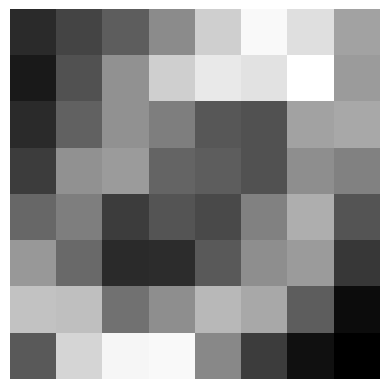

In [2]:
p_ml = np.average(Y, 0)
print(p_ml)
plt.figure()
plt.imshow(np.reshape(p_ml, (8,8)),
            interpolation="None",
            cmap='gray')
plt.axis('off')

## (e) 

The code is as follows. Note when $\alpha = \beta = 1$ MAP will be equal to ML parameters. Note MAP estimate will be strongly dominated by the prior parameter if $\sum x_d^{(i)}$ is very small (i.e. very few points are 1). On the other hand, with more data points, the dominance of prior parameters is less.

[0.14423077 0.22115385 0.29807692 0.43269231 0.63461538 0.75961538
 0.68269231 0.5        0.09615385 0.25961538 0.45192308 0.63461538
 0.71153846 0.69230769 0.77884615 0.48076923 0.14423077 0.30769231
 0.45192308 0.39423077 0.27884615 0.25961538 0.5        0.51923077
 0.20192308 0.45192308 0.48076923 0.31730769 0.29807692 0.25961538
 0.44230769 0.40384615 0.32692308 0.39423077 0.20192308 0.26923077
 0.24038462 0.40384615 0.53846154 0.26923077 0.47115385 0.33653846
 0.14423077 0.15384615 0.28846154 0.44230769 0.48076923 0.18269231
 0.59615385 0.58653846 0.35576923 0.44230769 0.56730769 0.51923077
 0.29807692 0.05769231 0.28846154 0.65384615 0.75       0.75961538
 0.42307692 0.20192308 0.06730769 0.01923077]


(-0.5, 7.5, 7.5, -0.5)

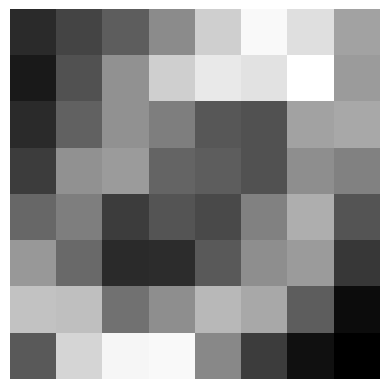

In [3]:
alpha = 3
beta = 3
p_map = (np.sum(Y, 0) + alpha - 1) / (N + alpha + beta - 2)
print(p_map)
plt.figure()
plt.imshow(np.reshape(p_map, (8,8)),
            interpolation="None",
            cmap='gray')
plt.axis('off')

# Q2

## (a) 

If $p_d = 0.5$ for all $d \in \{1, \dots, D\}$, we have for each $\mathbf{x}$:
$$P(\mathbf{x} | \mathbf{p} = 0.5*\mathbf{1_D}) = 0.5^D$$

## (b)

If $p_d$ is unknown but identical, we have:
$$P(\mathbf{x} | \mathbf{p}) = \prod_{d=1}^D p^{x_d}(1-p)^{1-x_d} = p^{\sum_{d=1}^Dx_d}(1-p)^{D-\sum_{d=1}^Dx_d}$$

## (c) 

If $p_d$ is separate and unknown, we have:
$$P(\mathbf{x} | \mathbf{p}) = \prod_{d=1}^D p_d^{x_d}(1-p_d)^{1-x_d}$$

Since all 3 models are equally likely _a_ _priori_, we have:
$$P(\mathcal{M}_i) = \frac{1}{3}$$
for $i = 1, 2, 3$.
And we have:
\begin{align*}
&p | \mathcal{M}_1 \sim \delta(0.5) \\
&p | \mathcal{M}_2 \sim \text{Unif}(0,1) \\
&\mathbf{p} | \mathcal{M}_3 \sim \text{Unif}(0,1)^D
\end{align*}
Likelihood for each model is:

\begin{align*}
P(\mathcal{D}|\mathbf{p}, \mathcal{M}_1) &= 0.5^{DN} \\
P(\mathcal{D}|\mathbf{p}, \mathcal{M}_2) &= p^{\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}}(1-p)^{DN-\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}} \\
P(\mathcal{D}|\mathbf{p}, \mathcal{M}_3) &= \prod_{i=1}^N\prod_{d=1}^D p_d^{x_d^{(i)}}(1-p_d)^{1-x_d^{(i)}} = \prod_{d=1}^{D} p_d^{\sum_{i=1}^Nx_d^{(i)}}(1-p_d)^{N-\sum_{i=1}^Nx_d^{(i)}}
\end{align*}

The marginal likelihood for each model is:

\begin{align*}
P(\mathcal{D}|\mathcal{M}_1) &= 0.5^{DN} \\
P(\mathcal{D}|\mathcal{M}_2) &= \int_0^1 p^{\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}}(1-p)^{DN-\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}} dp = \text{B}\left(\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)} + 1, DN-\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}+1\right)\\
P(\mathcal{D}|\mathcal{M}_3) &= \int_0^1 \cdots \int_0^1 \prod_{i=1}^N\prod_{d=1}^D p_d^{x_d^{(i)}}(1-p_d)^{1-x_d^{(i)}} dp_1\cdots dp_D\\
&= \prod_{d=1}^{D}\int_0^1 p_d^{\sum_{i=1}^Nx_d^{(i)}}(1-p_d)^{N-\sum_{i=1}^Nx_d^{(i)}}dp_d \\
&= \prod_{d=1}^{D}\text{B}\left(\sum_{i=1}^Nx_d^{(i)} + 1, N-\sum_{i=1}^Nx_d^{(i)}+1\right)
\end{align*}


We have posterior probability in each model:

\begin{align*}
P(\mathbf{p} | \mathcal{D},\mathcal{M}_1) &= \delta(0.5) \\
P(\mathbf{p} | \mathcal{D},\mathcal{M}_2) &= \frac{p^{\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}}(1-p)^{DN-\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}}}{\text{B}\left(\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)} + 1, DN-\sum_{i=1}^N\sum_{d=1}^Dx_d^{(i)}+1\right)}\\
P(\mathbf{p} | \mathcal{D},\mathcal{M}_3) &= \prod_{d=1}^{D}\frac{ p_d^{\sum_{i=1}^Nx_d^{(i)}}(1-p_d)^{N-\sum_{i=1}^Nx_d^{(i)}}}{\text{B}\left(\sum_{i=1}^Nx_d^{(i)} + 1, N-\sum_{i=1}^Nx_d^{(i)}+1\right)}
\end{align*}


$$P(\mathcal{M}_i | \mathcal{D}) \propto P(\mathcal{D} | \mathcal{M}_i)$$ 

given 

$$P(\mathcal{M}_i) = \frac{1}{3}$$

In [15]:
log_posterior_1 = D * N * np.log(0.5)
display(Math(rf'\mathcal{{M}}_1 \text{{ has unnormalised log posterior distribution }} {log_posterior_1}'))

<IPython.core.display.Math object>

In [ ]:
alpha_m2 = np.sum(Y) + 1
beta_m2 = D * N - np.sum(Y) + 1
from scipy.special import betaln
log_posterior_2 = betaln(alpha_m2, beta_m2)
display(Math(rf'\mathcal{{M}}_2 \text{{ has unnormalised log posterior distribution }} \log\text{B}({int(alpha_m2)}, {int(beta_m2)}) = {log_posterior_2}'))

<IPython.core.display.Math object>

In [ ]:
alphas_m3 = np.sum(Y, 0) + 1
betas_m3 = N - np.sum(Y, 0) + 1
log_posterior_3 = np.sum([betaln(this_alpha, this_beta) for this_alpha, this_beta in zip(alphas_m3, betas_m3)])
pairs_m3 = [(int(this_alpha), int(this_beta)) for this_alpha, this_beta in zip(alphas_m3, betas_m3)]
display(Math(rf'\mathcal{{M}}_3 \text{{ has unnormalised log posterior distribution }} \sum_d\log\text{B} = {log_posterior_3}'))

<IPython.core.display.Math object>

# Q3

## (a) 

We have

\begin{align*}
s^{(i)} &\sim Discrete(\mathbf{\pi}) \\
\mathbf{x}^{(i)} &\sim Bernoulli(\mathbf{p} | s^{(i)})
\end{align*}

where

\begin{align*}
\mathbf{\pi} &= (\pi_1, \dots, \pi_K)^T \\
\mathbf{p}_k &:= (\mathbf{p} | s^{(i)} = k) = (p_{k1}, \dots, p_{kD})^T
\end{align*}


We have likelihood

\begin{align*}
p(\mathcal{D} | P, \mathbf{\pi}) &= \prod_{i=1}^N\sum_{k=1}^K\pi_k\left(\prod_{d=1}^Dp_{kd}^{x_d^{(i)}}(1-p_{kd})^{1-x_d^{(i)}}\right) \\
&= \prod_{i=1}^N\sum_{k=1}^K\pi_k\exp\left(\Phi(\mathbf{p}_k)^T\mathbf{x}^{(i)} + \Phi_-(\mathbf{p}_k)^T\mathbf{1}_D\right)\\
&= \prod_{i=1}^N \mathbf{\pi}^T \exp\left(\Phi(P)\mathbf{x}^{(i)} + \Phi_-(P)\mathbf{1}_D\right)
\end{align*}

where

\begin{align*}
\Phi(p) &:= \log\left(\frac{p}{1-p}\right) \\ 
\Phi_-(p) &:= \log\left(1-p\right) \\
\mathbf{1}_D &:= (1, \dots, 1)^T \in \mathbb{R}_D
\end{align*}



## (b)
 

\begin{align*}
r_{nk} &\equiv p(s^{(n)} = k | \mathbf{x}^{(n)}, \mathbf{\pi}, P ) \\
& = \frac{p(\mathbf{x}^{(n)} | s^{(n)} = k , \mathbf{\pi}, P ) p(s^{(n)} = k | \mathbf{\pi}, P)}{\sum_k^K p(\mathbf{x}^{(n)} | s^{(n)} = k , \mathbf{\pi}, P ) p(s^{(n)} = k | \mathbf{\pi}, P)}\\
&= \frac{\pi_k\left(\prod_{d=1}^Dp_{kd}^{x_d^{(n)}}(1-p_{kd})^{1-x_d^{(n)}}\right)}{\sum_{k=1}^K\pi_k\left(\prod_{d=1}^Dp_{kd}^{x_d^{(n)}}(1-p_{kd})^{1-x_d^{(n)}}\right)} \\
&= \frac{\pi_k\exp\left(\Phi(\mathbf{p}_k)^T\mathbf{x}^{(n)} + \Phi_-(\mathbf{p}_k)^T\mathbf{1}_D\right)}{\mathbf{\pi}^T \exp\left(\Phi(P)\mathbf{x}^{(n)} + \Phi_-(P)\mathbf{1}_D\right)}
\end{align*}


## (c)

Denote

\begin{align*}
F(\mathbf{\pi}, P) &:= \mathbb{E}_{q(s^{(n)})}\left[\sum_n^N \log p\left(\mathbf{x}^{(n)}, s^{(n)} | \mathbf{\pi}, P\right)\right]\\
q_{nk} &:= q(s^{(n)} = k)
\end{align*}


We have 

\begin{align*}
F &= \sum_n^N\sum_k^Kq_{nk}\left(\log\pi_k + \sum_d^D\left(x_d^{(n)}\log\left(\frac{p_{kd}}{1-p_{kd}}\right) + \log\left(1-p_{kd}\right)\right)\right) \\
\frac{\partial F}{\partial p_{kd}} &= \sum_n^Nq_{nk}\left(x_d^{(n)}\left(\frac{1}{p_{kd}} + \frac{1}{1-p_{kd}}\right) - \frac{1}{p_{kd}}\right) = 0 \\
\frac{\partial F}{\partial \pi_k} + \lambda &= \sum_n^N \frac{q_{nk}}{\pi_k} + \lambda = 0 \\
\sum_k^K \pi_k &= 1
\end{align*}

where last 2 lines are due to Lagrange multiplier.

To solve them, we have

\begin{align*}
p_{kd}^* &= \frac{\sum_n q_{nk}x_d^{(n)}}{\sum_n q_{nk}} \\
\pi_k^* &= \frac{\sum_n q_{nk}}{N}
\end{align*}


If we set $q(s^{(n)} = k) := r_{nk}$, we have the maximising parameters as follows:

\begin{align*}
p_{kd}^* &= \frac{\sum_n r_{nk}x_d^{(n)}}{\sum_n r_{nk}} \\
\pi_k^* &= \frac{\sum_n r_{nk}}{N}
\end{align*}

So in M-step, we update the parameter $\mathbf{\pi}$ and $P$ based on the above.

## (d) 

The code is as follows.

In [3]:
import scipy.special
import copy

class EMAlgo_MoB:
    """
    EM algorithm for Mixture of Bernouli distribution
    """

    def __init__(self, X, K):
        # store train data into _data
        self._data = X
        # _N is the number of images, _D is the number of pixels
        self._N, self._D = X.shape
        self._K = K
        # _R is the matrix of responsibility r_{nk}
        self._R = None
        # _loglikelihood
        self._loglikelihood = []

    def calc_responsibility_and_likelihood(self, pi, P):
        assert len(pi) == self._K, ("Dimension of K in pi does not match", len(pi), self._K)
        assert P.shape[0] == self._K, ("Dimension of K in P does not match", P.shape[0], self._K)
        assert P.shape[1] == self._D, ("Dimension of D in P does not match", P.shape[1], self._D)
        assert abs(sum(pi) - 1.0) < 1.0e-8, "Sum of pi needs to be 1"
        # For stability issue, we cap P at 0.999 and floor it at 0.001
        P = np.fmax(0.001, np.fmin(0.999, P))
        Phi_m_P = np.log(1.0 - P)
        Phi_P = np.log(P) - Phi_m_P
        log_unnormalised_resp = self._data @ Phi_P.T + np.ones_like(self._data) @ Phi_m_P.T + np.log(pi)
        log_normaliser = scipy.special.logsumexp(log_unnormalised_resp, axis=1)
        self._loglikelihood.append(np.sum(log_normaliser))
        log_normaliser = log_normaliser.reshape((self._N, 1))
        log_normalised_resp = log_unnormalised_resp - log_normaliser
        self._R = np.exp(log_normalised_resp)

    def calc_E_step(self, pi, P, tolerence=1.0e-4):
        self.calc_responsibility_and_likelihood(pi, P)
        bStop = len(self._loglikelihood) > 1 and abs(self._loglikelihood[-1] / self._loglikelihood[-2] - 1) < tolerence
        return bStop

    def calc_M_step(self):
        sum_of_r_in_n = np.sum(self._R, axis=0)
        pi = sum_of_r_in_n / self._N
        P = (self._R.T @ self._data) / sum_of_r_in_n.reshape((len(sum_of_r_in_n), 1))
        return pi, P
    
    def run(self, init_pi, init_P, tolerence=1.0e-7, max_iteration=100):
        self._loglikelihood = []
        pi = copy.deepcopy(init_pi)
        P = copy.deepcopy(init_P)
        for _ in range(max_iteration):
            bStop = self.calc_E_step(pi, P, tolerence)
            if bStop:
                break
            pi, P = self.calc_M_step()
        return pi, P
    
    def diag(self):
        return self._loglikelihood
    
    def show_last_R(self):
        return self._R



Before running EM, we first examine the dataset we have.

In [21]:
print(F'Total number of data is {N}')

Total number of data is 100


In [22]:
print(np.sum(Y, axis=0))

[13. 21. 29. 43. 64. 77. 69. 50.  8. 25. 45. 64. 72. 70. 79. 48. 13. 30.
 45. 39. 27. 25. 50. 52. 19. 45. 48. 31. 29. 25. 44. 40. 32. 39. 19. 26.
 23. 40. 54. 26. 47. 33. 13. 14. 28. 44. 48. 17. 60. 59. 35. 44. 57. 52.
 29.  4. 28. 66. 76. 77. 42. 19.  5.  0.]


The last pixel is always 0 from 100 data points, which suggests $p_{kd} = 0, \forall k \in K$ with $d = 64$.

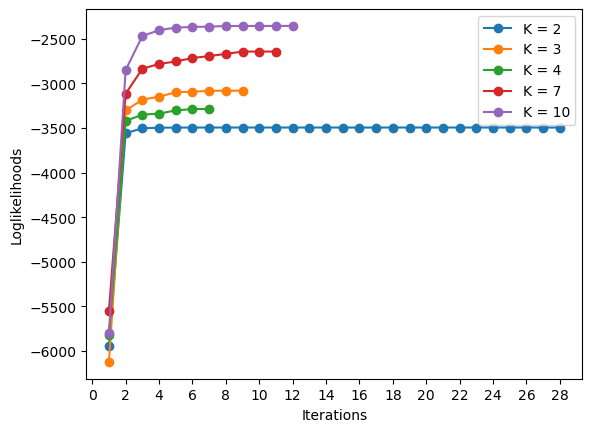

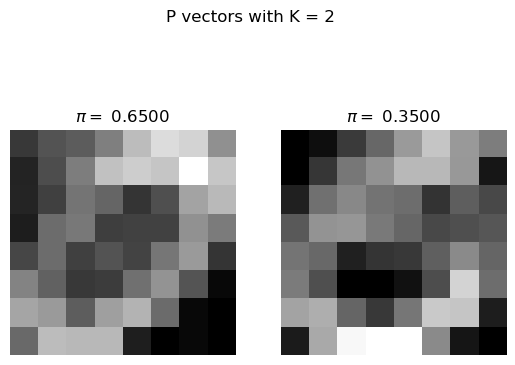

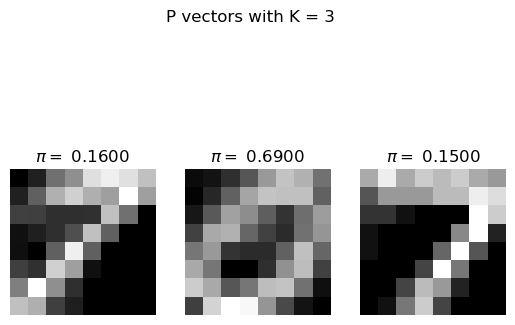

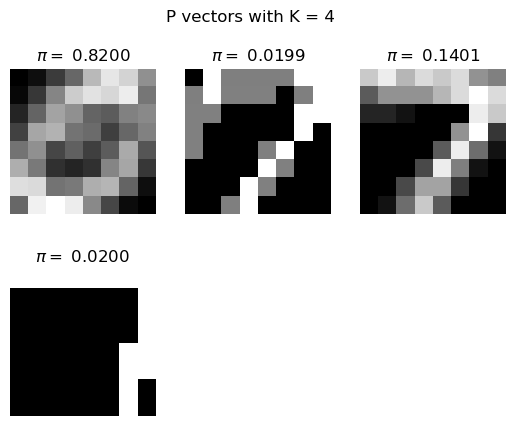

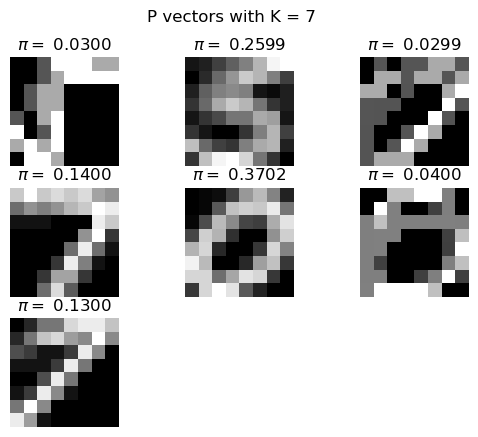

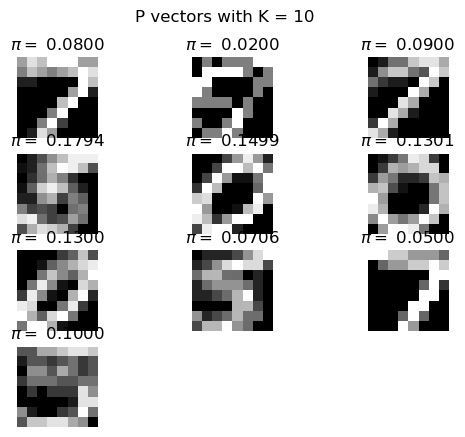

In [4]:
K = [2, 3, 4, 7, 10]
likelihoods = {}
pis = {}
Ps = {}
max_iter = 0
np.random.seed(0)
for k in K:
    init_pi = np.array(list(range(1, k+1))) / sum(range(1, k+1))
    init_P = np.random.rand(k, Y.shape[1])
    EM_algo = EMAlgo_MoB(Y, k)
    pi, P = EM_algo.run(init_pi, init_P)
    pis[k] = pi
    Ps[k] = P
    likelihoods[k] = EM_algo.diag()
    plt.plot(list(range(1, len(EM_algo.diag()) + 1)), EM_algo.diag(), marker='o', label=f'K = {k}', linestyle='-')
    max_iter = max(max_iter, len(EM_algo.diag()))
plt.xlabel('Iterations')
plt.ylabel('Loglikelihoods')
plt.xticks(range(0, max_iter + 1, 2))
plt.legend()
plt.show()

# for k, values in pis.items():
#     latex_P_str = r'P = \begin{bmatrix}' + \
#             r'\\'.join([' & '.join(['%.4f' % value for value in row]) for row in Ps[k]]) + \
#             r'\end{bmatrix}'
#     display(Math(
#         rf'K = {k}\\ \pi = \left[' + rf''.join(' , '.join(['%.4f' % value for value in values])) + r'\right] \\' + latex_P_str))

import math 
for k, likelihood in likelihoods.items():
    rows = math.ceil(k/3.0)
    fig, axs = plt.subplots(rows, min(3, k))
    axs = axs.flatten()
    for i in range(k):
        axs[i].imshow(Ps[k][i,:].reshape(8,8), interpolation='None', cmap='gray')
        axs[i].set_title(rf'$\pi=$ ' + '%.4f' % pis[k][i])
        axs[i].axis('off')
    for i in range(k, len(axs)):
        fig.delaxes(axs[i])
    fig.suptitle(f'P vectors with K = {k}')

## (e) 

We ran 30 repetitions for each $K$ with random initial points. We sorted $\pi$ and $P$, plotted $\pi$. 

- They do not obtain same solutions. Some of them are very close. This is due to that EM algorithm converges to local maximum and they went to different local maxima and hence difference $\pi$.
- This does depend on K.
- For higher $K$ it finds very good clusters. One can tell clear numbers (7, 5, 0 with slightly different writings) written in pixels. The responsibilities show either 0 or 1, indicating given the data point, one can clearly tell which cluster it is from.
- To further improve the model, one can think to add correlation bewteen adjacent pixels, i.e. adjacent pixels are not independent.

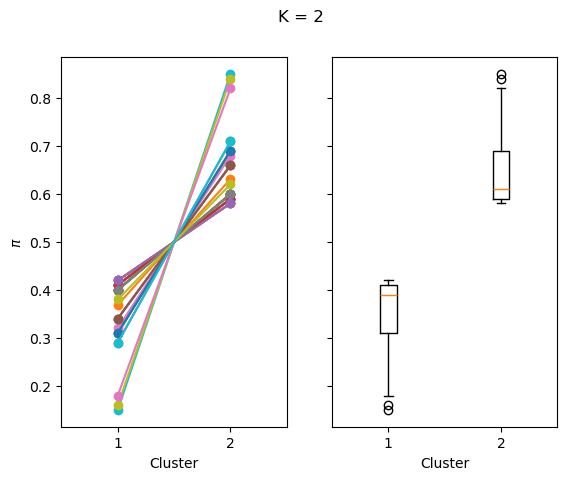

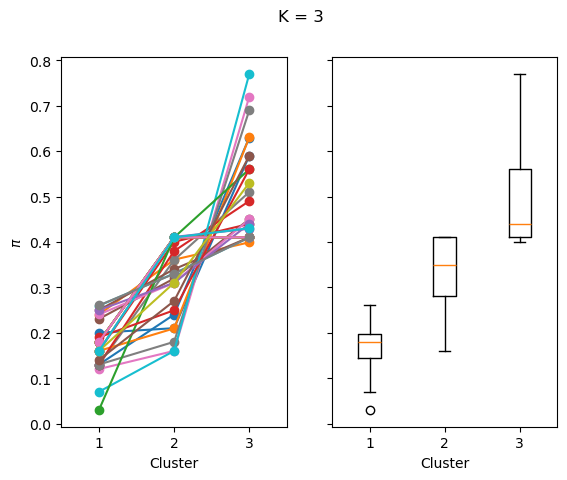

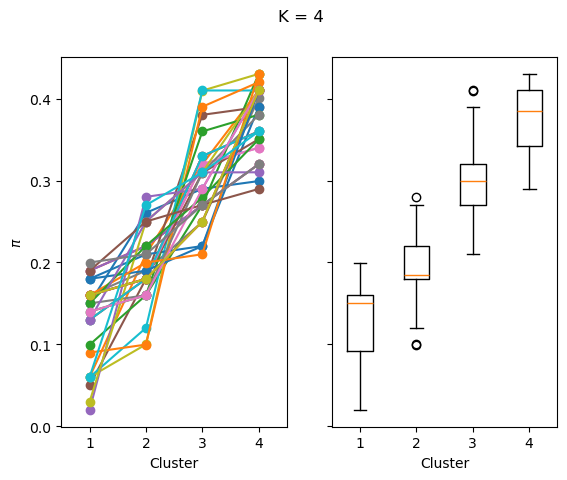

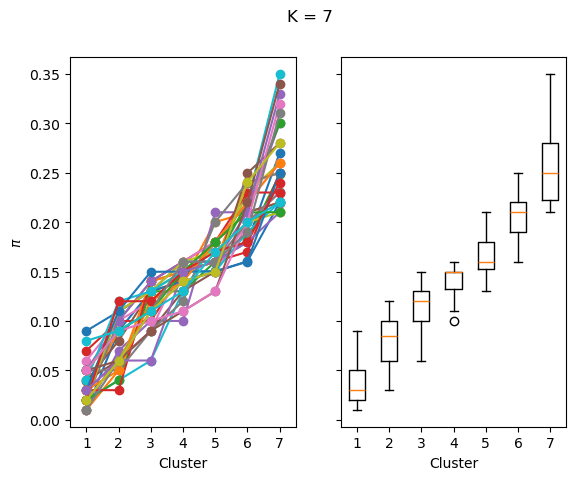

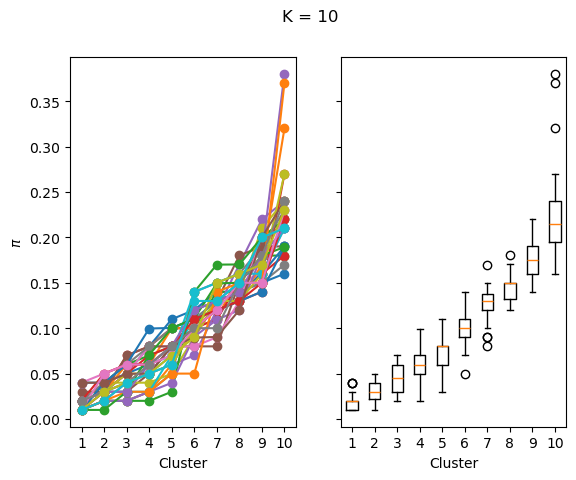

In [ ]:
K = [2, 3, 4, 7, 10]
reps = 30
np.random.seed(1994)
pi_params = {}
P_params = {}
log_likelihoods = {}
R_params = {}
for k in K:
    pi_results = []
    P_results = []
    log_likelihood_results = []
    R_results = []
    fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)
    for _ in range(reps):
        k_random = np.random.rand(k)
        init_pi = k_random / sum(k_random)
        init_P = np.random.rand(k, Y.shape[1])
        EM_algo = EMAlgo_MoB(Y, k)
        pi, P = EM_algo.run(init_pi, init_P)
        # We sort pi and P together based on pi
        pi, P = zip(*sorted(zip(pi, P), key=lambda x:x[0]))
        pi = np.array(pi)
        P = np.array(P)
        pi_results.append(pi)
        P_results.append(P)
        log_likelihood_results.append(EM_algo.diag()[-1])
        R_results.append(EM_algo.show_last_R())
        ax1.plot(list(range(1, k + 1)), pi, marker='o', linestyle='-')
    ax1.set(xlabel = 'Cluster', ylabel = r'$\pi$', xticks=range(1, k + 1))
    ax2.boxplot(np.array(pi_results))
    ax2.set(xlabel = 'Cluster', xticks=range(1, k + 1))
    fig.suptitle(f'K = {k}')
    pi_params[k] = pi_results
    P_params[k] = P_results
    log_likelihoods[k] = log_likelihood_results
    R_params[k] = R_results

Note responsibilities for each $K$ are either 0 or 1. We do not output here because they are very large matrices.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

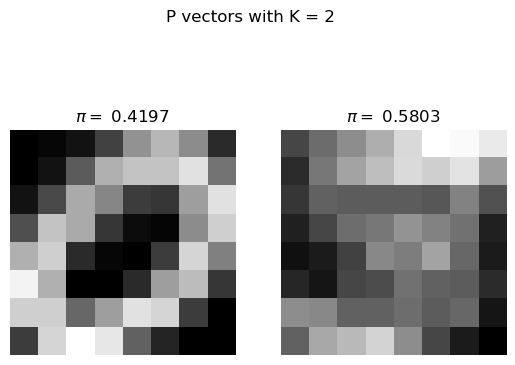

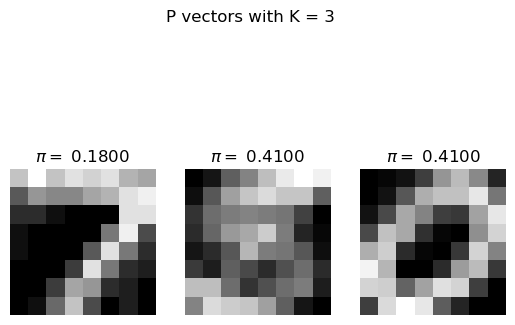

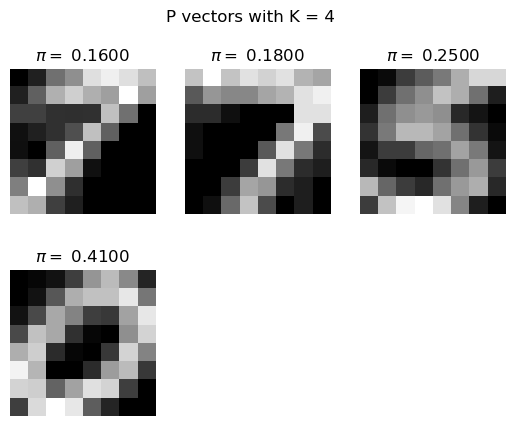

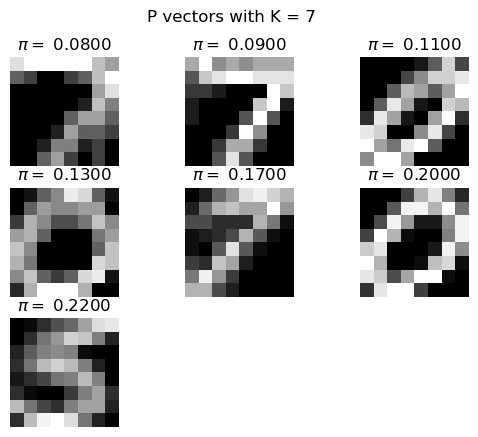

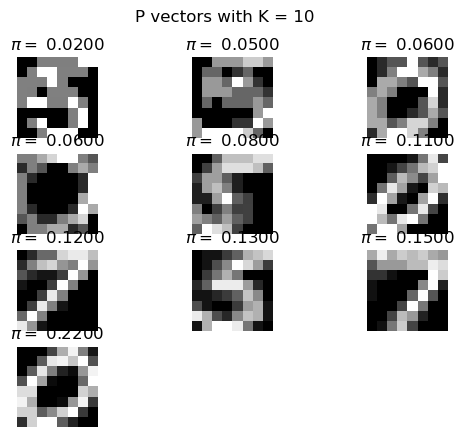

In [6]:
import math
# We pick largest log likelihoods in each K and plot learnt P
for k, likelihood in log_likelihoods.items():
    idx, max_likelihood = max(enumerate(likelihood), key=lambda x: x[1])
    pi_max = pi_params[k][idx]
    P_max = P_params[k][idx]
    # latex_R_str = r'r = \begin{bmatrix}' + \
    #         r'\\'.join([' & '.join(['%.4f' % value for value in row]) for row in R_params[k][idx]]) + \
    #         r'\end{bmatrix}'
    display(Math(
        rf'K = {k}\\ \pi' + r'\text{ with max likelihood is }' + rf'\left[' + rf''.join(' , '.join(['%.4f' % value for value in pi_max])) + r'\right]'))
    rows = math.ceil(k/3.0)
    fig, axs = plt.subplots(rows, min(3, k))
    axs = axs.flatten()
    for i in range(k):
        axs[i].imshow(P_max[i, :].reshape(8,8), interpolation='None', cmap='gray')
        axs[i].set_title(rf'$\pi=$ ' + '%.4f' % pi_max[i])
        axs[i].axis('off')
    for i in range(k, len(axs)):
        fig.delaxes(axs[i])
    fig.suptitle(f'P vectors with K = {k}')

## (f)

In [8]:
log_likelihoods_K = [value[-1] for value in likelihoods.values()]
for i, k in enumerate(K):
    display(Math(rf'K = {k}\\' + r'\text{loglikelihood in binary is }' + f'{log_likelihoods_K[i] / np.log(2)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

- The negative log likelihood is the cross-entropy between true data and the model distribution. The higher the value of negative log likelihood, the better the model fit.
- The higher the absolute log likelihood in bits, the more bits are required to encode the data. 
- According to minimum description length principle, the best model is the one that compresses the data the most and it requires the fewest bits to describe. 
- The naive way of encoding the $100 \times 64$ binary data requires 6400 bits.
- Log likehood in bits provides a way of compressing the 6400 bits data.

In [9]:
# gzip the data
import gzip

flattened_Y = np.ndarray.flatten(Y)
reshaped_Y = np.array([int(y) for y in flattened_Y]).reshape(int(len(flattened_Y) / 8), 8)
byte_list = []
for group in reshaped_Y:
    byte = 0
    for bit in group:
        byte = (byte << 1) | bit
    byte_list.append(byte)
byte_data = bytes(byte_list)
compressed_data = gzip.compress(byte_data)
print(f'Gzip compression requires bits {len(compressed_data) * 8}')

Gzip compression requires bits 5416


- Using gzip method, it requires bits 5416, which is larger than any of mixture models we trained. The reason why it has the difference is gzip uses generic and efficient method to compress.

## (g) 

We have 
* $K$ parameters from $\mathbf{\pi}$ but we only need to encode $K-1$ because they sum to 1
* $K \times D$ parameters from $P$. In total we have $K(D+1) - 1$ parameters
* $N$ data points, each assign to one of $K$ mixture group. We need $N\lceil{\log_2K}\rceil$
* Given the precision is 4 digits. We need $\lceil{4\log_210}\rceil = 14$ bits
* So in total we need $14K(D+1) - 14 + N\lceil{\log_2K}\rceil$ bits.

Substituting $K$, $D$ and $N$ and calculating the total cost, we have:

In [10]:
for i, k in enumerate(K):
    display(Math(rf'K = {k}\\' + r'\text{total cost in binary is }' + f'{-log_likelihoods_K[i] / np.log(2) + 14 * k * (D + 1) - 14 + N * math.ceil(np.log2(k))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

- The total cost is much higher than gzip method
- For higher K, we have higher cost
- There is a trade-off between lower negative log likelihood and model complexity in total encoding cost. 

If we lower the precision to 2 digits, we only need 7 bits for each parameter. The total cost would be:

In [11]:
for i, k in enumerate(K):
    display(Math(rf'K = {k}\\' + r'\text{total cost in binary is }' + f'{-log_likelihoods_K[i] / np.log(2) + 7 * k * (D + 1) - 7 + N * math.ceil(np.log2(k))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Still higher than gzip unfortunately.

# Q4

## (a) 

We copy the code from ssm_kalman.py file here.

In [128]:
# -*- coding: utf-8 -*-

"""
    File name: ssm_kalman.py
    Description: a re-implementation of the Kalman filter for http://www.gatsby.ucl.ac.uk/teaching/courses/ml1
    Author: Roman Pogodin / Maneesh Sahani (matlab version)
    Date created: October 2018
    Python version: 3.6
"""

def ensure_positive_definite(A):
    """
    Adjusts matrix A to be positive definite.
    """
    A = (A + A.T) / 2
    min_eig = np.min(np.real(np.linalg.eigvals(A)))
    if min_eig < 0:
        A += np.eye(A.shape[0]) * (-min_eig + 1e-4)
    return A

def run_ssm_kalman(X, y_init, Q_init, A, Q, C, R, mode='smooth'):
    """
    Calculates kalman-smoother estimates of SSM state posterior.
    :param X:       data, [d, t_max] numpy array
    :param y_init:  initial latent state, [k,] numpy array
    :param Q_init:  initial variance, [k, k] numpy array
    :param A:       latent dynamics matrix, [k, k] numpy array
    :param Q:       innovariations covariance matrix, [k, k] numpy array
    :param C:       output loading matrix, [d, k] numpy array
    :param R:       output noise matrix, [d, d] numpy array
    :param mode:    'forw' or 'filt' for forward filtering, 'smooth' for also backward filtering
    :return:
    y_hat:      posterior mean estimates, [k, t_max] numpy array
    V_hat:      posterior variances on y_t, [t_max, k, k] numpy array
    V_joint:    posterior covariances between y_{t+1}, y_t, [t_max, k, k] numpy array
    likelihood: conditional log-likelihoods log(p(x_t|x_{1:t-1})), [t_max,] numpy array
    """
    d, k = C.shape
    t_max = X.shape[1]

    # dimension checks
    assert np.all(X.shape == (d, t_max)), "Shape of X must be (%d, %d), %s provided" % (d, t_max, X.shape)
    assert np.all(y_init.shape == (k,)), "Shape of y_init must be (%d,), %s provided" % (k, y_init.shape)
    assert np.all(Q_init.shape == (k, k)), "Shape of Q_init must be (%d, %d), %s provided" % (k, k, Q_init.shape)
    assert np.all(A.shape == (k, k)), "Shape of A must be (%d, %d), %s provided" % (k, k, A.shape)
    assert np.all(Q.shape == (k, k)), "Shape of Q must be (%d, %d), %s provided" % (k, k, Q.shape)
    assert np.all(C.shape == (d, k)), "Shape of C must be (%d, %d), %s provided" % (d, k, C.shape)
    assert np.all(R.shape == (d, d)), "Shape of R must be (%d, %d), %s provided" % (d, d, R.shape)

    y_filt = np.zeros((k, t_max))  # filtering estimate: \hat(y)_t^t
    V_filt = np.zeros((t_max, k, k))  # filtering variance: \hat(V)_t^t
    y_hat = np.zeros((k, t_max))  # smoothing estimate: \hat(y)_t^T
    V_hat = np.zeros((t_max, k, k))  # smoothing variance: \hat(V)_t^T
    K = np.zeros((t_max, k, X.shape[0]))  # Kalman gain
    J = np.zeros((t_max, k, k))  # smoothing gain
    likelihood = np.zeros(t_max)  # conditional log-likelihood: p(x_t|x_{1:t-1})

    I_k = np.eye(k)

    # forward pass

    V_pred = Q_init
    y_pred = y_init

    for t in range(t_max):
        x_pred_err = X[:, t] - C @ y_pred
        V_x_pred = C @ V_pred @ C.T + R

        V_x_pred = ensure_positive_definite(V_x_pred)
        L = np.linalg.cholesky(V_x_pred)
        log_det = 2 * np.sum(np.log(np.diag(L)))
        V_x_pred_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(L.shape[0])))
        
        likelihood[t] = -0.5 * (d * np.log(2 * np.pi) + log_det + x_pred_err.T @ V_x_pred_inv @ x_pred_err)

        K[t] = V_pred @ C.T @ V_x_pred_inv

        y_filt[:, t] = y_pred + K[t] @ x_pred_err
        V_filt[t] = V_pred - K[t] @ C @ V_pred

        # symmetrise the variance to avoid numerical drift
        V_filt[t] = ensure_positive_definite(V_filt[t])

        y_pred = A @ y_filt[:, t]
        V_pred = A @ V_filt[t] @ A.T + Q
        V_pred = ensure_positive_definite(V_pred)

    # backward pass

    if mode == 'filt' or mode == 'forw':
        # skip if filtering/forward pass only
        y_hat = y_filt
        V_hat = V_filt
        V_joint = None
    else:
        V_joint = np.zeros_like(V_hat)
        y_hat[:, -1] = y_filt[:, -1]
        V_hat[-1] = V_filt[-1]

        for t in range(t_max - 2, -1, -1):
            V_pred = A @ V_filt[t] @ A.T + Q
            V_pred = ensure_positive_definite(V_pred)
            V_pred_inv = np.linalg.inv(V_pred)

            J[t] = V_filt[t] @ A.T @ V_pred_inv
            y_hat[:, t] = y_filt[:, t] + J[t] @ (y_hat[:, t + 1] - A @ y_filt[:, t])
            V_hat[t] = V_filt[t] + J[t] @ (V_hat[t + 1] - V_pred) @ J[t].T

            V_hat[t] = ensure_positive_definite(V_hat[t])

        V_joint[-2] = (I_k - K[-1].dot(C)).dot(A).dot(V_filt[-2])
        V_joint[-2] = ensure_positive_definite(V_joint[-2])

        for t in range(t_max - 3, -1, -1):
            V_joint[t] = V_filt[t + 1] @ J[t].T + J[t + 1] @ (V_joint[t + 1] - A @ V_filt[t + 1]) @ J[t].T
            V_joint[t] = ensure_positive_definite(V_joint[t])

    return y_hat, V_hat, V_joint, likelihood

In [129]:
def log_det(A):
    """
    function to calculate log |A|, where A is a square matrix
    """
    L = np.linalg.cholesky(A)
    diag = np.diagonal(L)
    det = 2.0 * np.sum(np.log(diag))
    return det

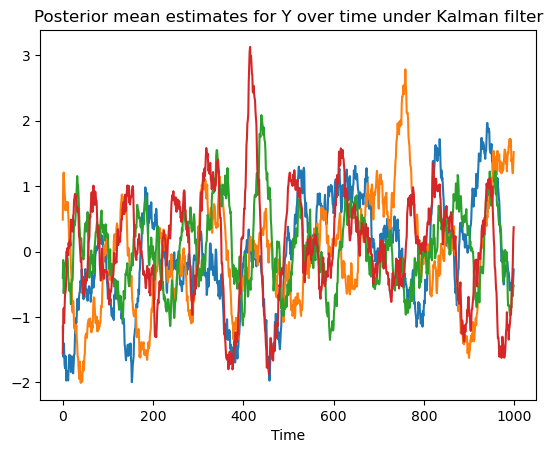

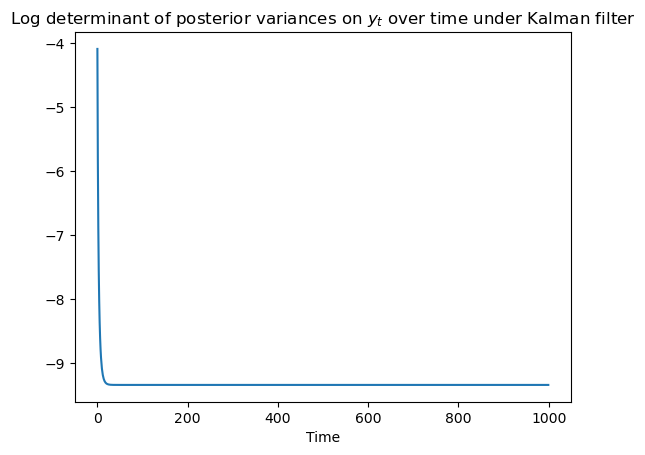

In [130]:
X = np.loadtxt('ssm_spins.txt')
A = 0.99 * np.array([[math.cos(math.pi / 90.0), -math.sin(math.pi / 90.0), 0, 0],
                     [math.sin(math.pi / 90.0), math.cos(math.pi / 90.0), 0, 0],
                     [0, 0, math.cos(math.pi / 45.0), -math.sin(math.pi / 45.0)],
                     [0, 0, math.sin(math.pi / 45.0), math.cos(math.pi / 45.0)]])
Q = np.eye(A.shape[0]) - A @ A.T
C = np.array([[1, 0, 1, 0],
              [0, 1, 0, 1],
              [1, 0, 0, 1],
              [0, 0, 1, 1],
              [0.5, 0.5, 0.5, 0.5]])

R = np.eye(X.shape[1])

y0 = np.zeros(4)
Q0 = np.eye(4)

Y, V, _, L = run_ssm_kalman(X.T, y0, Q0, A, Q, C, R, 'filt')
plt.figure()
plt.plot(Y.T)
plt.xlabel('Time')
plt.title('Posterior mean estimates for Y over time under Kalman filter')
plt.show()
log_dets = np.array(list(map(log_det, V)))
plt.figure()
plt.plot(log_dets)
plt.xlabel('Time')
plt.title(r'Log determinant of posterior variances on $y_t$ over time under Kalman filter')
plt.show()

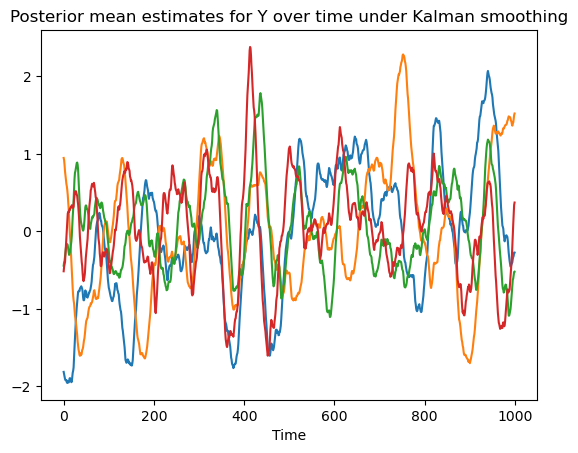

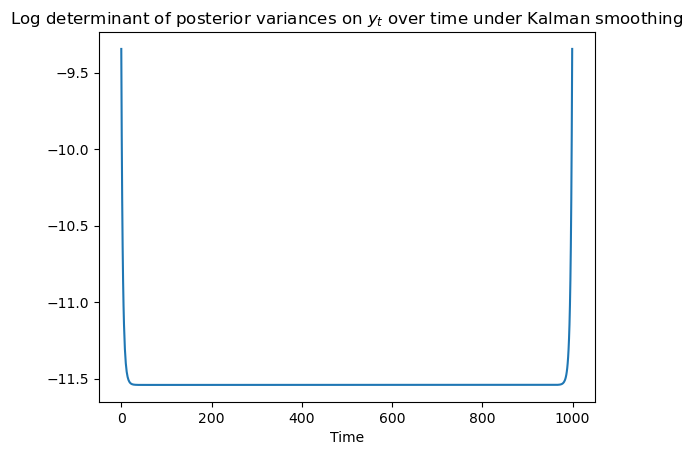

In [131]:
Y, V, Vj, L = run_ssm_kalman(X.T, y0, Q0, A, Q, C, R, 'smooth')
plt.figure()
plt.plot(Y.T)
plt.xlabel('Time')
plt.title('Posterior mean estimates for Y over time under Kalman smoothing')
plt.show()
log_dets = np.array(list(map(log_det, V)))
plt.figure()
plt.plot(log_dets)
plt.xlabel('Time')
plt.title(r'Log determinant of posterior variances on $y_t$ over time under Kalman smoothing')
plt.show()

In filtering, we calculate $\mathbb{E}\left[\mathbf{y}_t \mid \mathbf{x}_1, \dots, \mathbf{x}_t\right]$ and $\mathbb{V}\left[\mathbf{y}_t \mid \mathbf{x}_1, \dots, \mathbf{x}_t\right]$. Specifically, 
$$P(\mathbf{y}_t \mid \mathbf{x}_1, \dots, \mathbf{x}_t) = \mathcal{N}\left(\hat{\mathbf{y}}_t^{t-1} + K_t\left(\mathbf{x}_t - C\hat{\mathbf{y}}_t^{t-1}\right),\hat{V}_t^{t-1} - K_tC\hat{V}_t^{t-1}\right)$$
The plot of log determinant of posterior variance is decreasing, showing $\hat{V}_t^{t}$ is smaller over the time.

In smoothing, we calculate $\mathbb{E}\left[\mathbf{y}_t \mid \mathbf{x}_1, \dots, \mathbf{x}_T\right]$ and $\mathbb{V}\left[\mathbf{y}_t \mid \mathbf{x}_1, \dots, \mathbf{x}_T\right]$. The plot of posterior mean estmiate of $\mathbf{y}_t$ is much smoothier than Kalman filtering case because it uses both forward (past data) and backward (future data) to provide more accurate and refined estimate. However, as the data goes to $T$, we have less future data to do the smoothing so the effect will be not as good as that in the middle. This can be verified in the log determinant of posterior variance plot where we can see the log number decreases and increases again.

## (b) 

Since we have 
$$p(\mathbf{x}_t\mid\mathbf{y}_t) \propto |R^{-1}|^{\frac{1}{2}} \exp\left[-\frac{1}{2}\left(\mathbf{x}_t - C\mathbf{y}_t\right)^\intercal R^{-1}\left(\mathbf{x}_t - C\mathbf{y}_t\right)\right]$$
So

\begin{align*}
\mathbb{E}_q\left[\sum_t\log p(\mathbf{x}_t\mid\mathbf{y}_t)\right] &= \frac{T}{2}\log|R^{-1}| - \frac{1}{2}Tr\left[\left(\sum_t\mathbf{x}_t\mathbf{x}_t^\intercal\right) R^{-1}\right] + Tr\left[C\sum_t\left(\mathbb{E}_q\left[\mathbf{y}_t\right]\mathbf{x}_t^\intercal\right)R^{-1}\right] \\
&-\frac{1}{2}Tr\left[C\mathbb{E}_q\left[\sum_t\mathbf{y}_t\mathbf{y}_t^\intercal\right]C^\intercal R^{-1}\right]
\end{align*}


Denote the above expectation as $\mathcal{l}$ and take the derivate regarding $R^{-1}$.


\begin{align*}
\frac{\partial \mathcal{l}}{\partial R^{-1}} &= \frac{T}{2}R - \frac{1}{2}\left(\sum_t\mathbf{x}_t\mathbf{x}_t^\intercal\right) + \sum_t\left(\mathbf{x}_t\mathbb{E}_q\left[\mathbf{y}_t^\intercal\right]\right) C^\intercal - \frac{1}{2}C\mathbb{E}_q\left[\sum_t\mathbf{y}_t\mathbf{y}_t^\intercal\right]C^\intercal
\end{align*}


Set it to 0 and get
$$R_{\text{new}} = \frac{1}{T}\left[\sum_t\mathbf{x}_t\mathbf{x}_t^\intercal - 2\sum_t\left(\mathbf{x}_t\mathbb{E}_q\left[\mathbf{y}_t^\intercal\right]\right) C^\intercal + C\mathbb{E}_q\left[\sum_t\mathbf{y}_t\mathbf{y}_t^\intercal\right]C^\intercal\right]$$

Plug into $C$ with $C_{\text{new}}$ we can get
$$R_{\text{new}} = \frac{1}{T}\left[\sum_t\mathbf{x}_t\mathbf{x}_t^\intercal - \sum_t\left(\mathbf{x}_t\mathbb{E}_q\left[\mathbf{y}_t^\intercal\right]\right) C_{\text{new}}^\intercal\right]$$

Similar to deal with
$$p(\mathbf{y}_{t+1}\mid\mathbf{y}_t) \propto |Q^{-1}|^{\frac{1}{2}} \exp\left[-\frac{1}{2}\left(\mathbf{y}_{t+1} - A\mathbf{y}_t\right)^\intercal Q^{-1}\left(\mathbf{y}_{t+1} - A\mathbf{y}_t\right)\right]$$
So

\begin{align*}
\mathbb{E}_q\left[\sum_{t=1}^{T-1}\log p(\mathbf{y}_{t+1}\mid\mathbf{y}_t)\right] &= \frac{T-1}{2}\log|Q^{-1}| - \frac{1}{2}Tr\left[\mathbb{E}_q\left[\sum_{t=1}^{T-1}\mathbf{y}_{t+1}\mathbf{y}_{t+1}^\intercal\right] Q^{-1}\right] + Tr\left[A\mathbb{E}_q\left[\sum_{t=1}^{T-1}\mathbf{y}_t\mathbf{y}_{t+1}^\intercal\right]Q^{-1}\right] \\
&-\frac{1}{2}Tr\left[A\mathbb{E}_q\left[\sum_{t=1}^{T-1}\mathbf{y}_t\mathbf{y}_t^\intercal\right]A^\intercal Q^{-1}\right]
\end{align*}


Taking derivative, setting it to 0 and replace $A$ with $A_{\text{new}}$ to get
$$Q_{\text{new}} = \frac{1}{T-1}\left[\mathbb{E}_q\left[\sum_{t=1}^{T-1}\mathbf{y}_{t+1}\mathbf{y}_{t+1}^\intercal\right]-\mathbb{E}_q\left[\sum_{t=1}^{T-1}\mathbf{y}_{t}\mathbf{y}_{t+1}^\intercal\right]A_{\text{new}}^\intercal\right]$$

In [132]:
class EMAlgo_LGSSM:
    """
    EM algorithm for LGSSM
    """

    def __init__(self, X, y_init, Q_init):
        """
        _data: a [t_max, d] numpy array for training
        _y_init: initial latent state, a [k, ] numpy array
        _Q_init: initial variance, a [k, k] numpy array
        """
        self._data = X
        self._y_init = y_init
        self._Q_init = Q_init

    def calc_E_step(self, A, Q, C, R):
        """
        proposal density q^*(y) = p(y_{1:T} | x_{1:T}) 
        We need to update y_hats in this step with the new parameter
        We should use smoothing
        """
        y_hat, V_hat, V_joint, likelihood = run_ssm_kalman(self._data.T, self._y_init, self._Q_init, A, Q, C, R, 'smooth')
        return y_hat, V_hat, V_joint, likelihood
    
    def calc_M_step(self, y_hat, V_hat, V_joint):
        """
        We need them to calculate new A, Q, R and C
        """
        T_max = V_hat.shape[0]
        k = V_hat.shape[1]
        d = self._data.shape[1]
        sum_of_y_yT = np.zeros((k, k))
        sum_of_y_yT_prev = np.zeros((k, k))
        sum_of_x_xT = np.zeros((d, d))
        sum_of_x_yT = np.zeros((d, k))
        sum_of_y_lag_y_T = np.zeros((k, k))
        for t in range(T_max):
            sum_of_y_yT += V_hat[t] + np.outer(y_hat[:,t], y_hat[:,t])
            sum_of_x_xT += np.outer(self._data[t], self._data[t])
            sum_of_x_yT += np.outer(self._data[t], y_hat[:,t])
            if t > 0:
                sum_of_y_lag_y_T += V_joint[t-1] + np.outer(y_hat[:,t], y_hat[:,t-1])
                sum_of_y_yT_prev += V_hat[t - 1] + np.outer(y_hat[:, t - 1], y_hat[:, t - 1])
        A_new = sum_of_y_lag_y_T @ np.linalg.inv(sum_of_y_yT_prev)
        C_new = sum_of_x_yT @ np.linalg.inv(sum_of_y_yT)
        R_new = (sum_of_x_xT - sum_of_x_yT @ C_new.T) / T_max
        Q_new = (sum_of_y_yT_prev - sum_of_y_lag_y_T @ A_new.T) / (T_max - 1)

        Q_new = ensure_positive_definite(Q_new)
        R_new = ensure_positive_definite(R_new)
        return A_new, Q_new, C_new, R_new
    
    def run(self, A_init, Q_init, C_init, R_init, max_iter=50):
        self._loglikelihood = []
        this_A = copy.deepcopy(A_init)
        this_Q = copy.deepcopy(Q_init)
        this_C = copy.deepcopy(C_init)
        this_R = copy.deepcopy(R_init)
        for _ in range(max_iter):
            y_hat, V_hat, V_joint, likelihood = self.calc_E_step(this_A, this_Q, this_C, this_R)
            self._loglikelihood.append(np.sum(likelihood))
            this_A, this_Q, this_C, this_R = self.calc_M_step(y_hat, V_hat, V_joint)
        return this_A, this_Q, this_C, this_R
    
    def diag(self):
        return np.array(self._loglikelihood)
    

In [139]:
EM_SSM = EMAlgo_LGSSM(X, y0, Q0)
A_opt, Q_opt, C_opt, R_opt = EM_SSM.run(A, Q, C, R, 50)
diag = EM_SSM.diag()

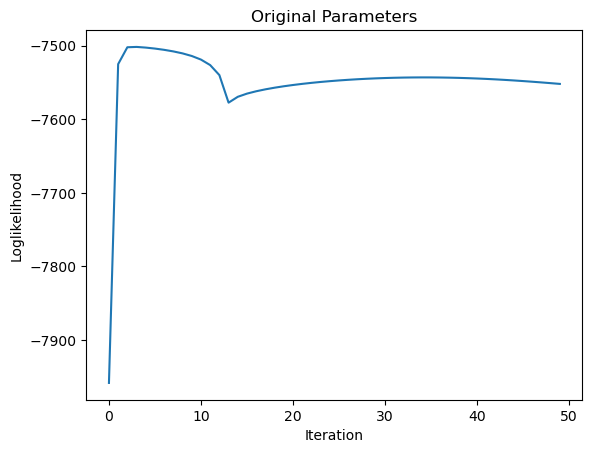

In [140]:
plt.figure()
plt.plot(diag)
plt.xlabel('Iteration')
plt.ylabel('Loglikelihood')
plt.title('Original Parameters')
plt.show()

In [141]:
latex_A_str = r'A^* = \begin{bmatrix}' + \
            r'\\'.join([' & '.join(['%.2g' % value for value in row]) for row in A_opt]) + \
            r'\end{bmatrix} \\'
latex_Q_str = r'Q^* = \begin{bmatrix}' + \
            r'\\'.join([' & '.join(['%.2g' % value for value in row]) for row in Q_opt]) + \
            r'\end{bmatrix} \\'
latex_C_str = r'C^* = \begin{bmatrix}' + \
            r'\\'.join([' & '.join(['%.2g' % value for value in row]) for row in C_opt]) + \
            r'\end{bmatrix} \\'
latex_R_str = r'R^* = \begin{bmatrix}' + \
            r'\\'.join([' & '.join(['%.2g' % value for value in row]) for row in R_opt]) + \
            r'\end{bmatrix} \\'
display(Math(latex_A_str + latex_Q_str + latex_C_str + latex_R_str))

<IPython.core.display.Math object>

In [148]:
# Randomly choose 10 set of parameters
diags = [diag]
As = [A_opt]
Qs = [Q_opt]
Cs = [C_opt]
Rs = [R_opt]
np.random.seed(1994)
for _ in range(10):
    random_A = np.random.uniform(-1, 1, A.shape)
    random_Q = np.eye(Q.shape[0]) + np.random.uniform(0, 1, Q.shape)
    random_Q = (random_Q + random_Q.T) / 2.0
    random_C = np.random.uniform(0, 1, C.shape)
    random_R = np.eye(R.shape[0]) + np.random.uniform(0, 1, R.shape)
    random_R = (random_R + random_R.T) / 2.0
    try:
        this_best_A, this_best_Q, this_best_C, this_best_R = EM_SSM.run(random_A, random_Q, random_C, random_R)
        this_diag = EM_SSM.diag()
        diags.append(this_diag)
        As.append(this_best_A)
        Qs.append(this_best_Q)
        Cs.append(this_best_C)
        Rs.append(this_best_R)
    except:
        continue

In [150]:
np.random.seed(2000)
for _ in range(5):
    random_A = np.random.uniform(-1, 1, A.shape)
    random_Q = np.eye(Q.shape[0]) + np.random.uniform(0, 1, Q.shape)
    random_Q = (random_Q + random_Q.T) / 2.0
    random_C = np.random.uniform(0, 1, C.shape)
    random_R = np.eye(R.shape[0]) + np.random.uniform(0, 1, R.shape)
    random_R = (random_R + random_R.T) / 2.0
    try:
        this_best_A, this_best_Q, this_best_C, this_best_R = EM_SSM.run(random_A, random_Q, random_C, random_R)
        this_diag = EM_SSM.diag()
        diags.append(this_diag)
        As.append(this_best_A)
        Qs.append(this_best_Q)
        Cs.append(this_best_C)
        Rs.append(this_best_R)
    except:
        continue

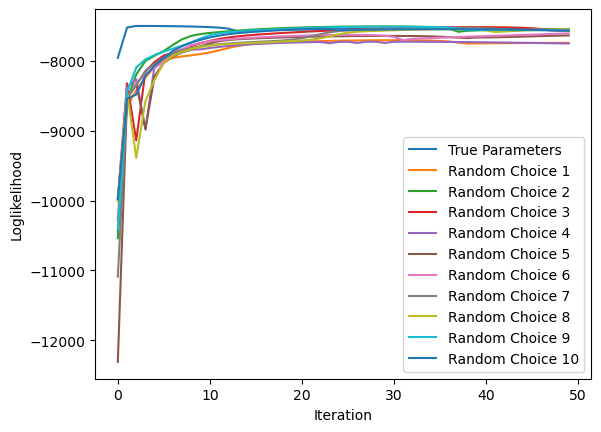

In [166]:
plt.figure()
for _, _diag in enumerate(diags):
    label = 'True Parameters' if _ == 0 else f'Random Choice {_}'
    plt.plot(_diag, label=label)
    plt.xlabel('Iteration')
    plt.ylabel('Loglikelihood')
plt.legend()
plt.show()

* True parameters have largest loglikelihood at initialisation
* Loglikelihood at convergence are similar across different choices. But all are close to initial true parameters.
* True parameter choice does not converge immediately because the randomness and finite sampling of our data. As the sample size increases to infinity, it will be more likely to converge to true parameters.
* There are numerical instability so that we see loglikelihood increased a bit and decreased and leveled off in true parameter set. The numerical instability mostly comes from non-positive definite covariance matrix.
* Numerical instability may also lead to drifting away from the true parameters.
* If running more iterations, there could be oscillations in loglikelihood. This could also be from the numerical instability issue.

## (c)

In [169]:
X_test = np.loadtxt('ssm_spins_test.txt')
parameter_names = []
loglikelihoods_among_parameters = []
_, __, ___, this_likelihood = run_ssm_kalman(X_test.T, y0, Q0, A, Q, C, R, 'filt')
parameter_names.append('True Parameter')
loglikelihoods_among_parameters.append(np.sum(this_likelihood))
_, __, ___, this_likelihood = run_ssm_kalman(X_test.T, y0, Q0, A_opt, Q_opt, C_opt, R_opt, 'filt')
parameter_names.append('EM on True Parameter')
loglikelihoods_among_parameters.append(np.sum(this_likelihood))
for i in range(1, len(As)):
    _, __, ___, this_likelihood = run_ssm_kalman(X_test.T, y0, Q0, As[i], Qs[i], Cs[i], Rs[i], 'filt')
    parameter_names.append(f'EM on Random {i}')
    loglikelihoods_among_parameters.append(np.sum(this_likelihood))

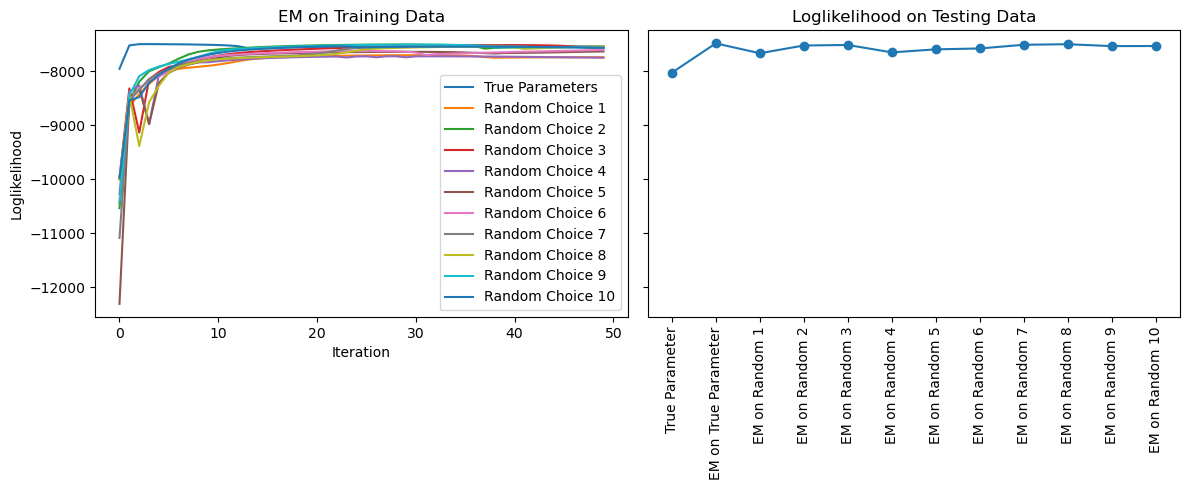

In [192]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = [12,5], sharey=True)
for _, _diag in enumerate(diags):
    label = 'True Parameters' if _ == 0 else f'Random Choice {_}'
    ax1.plot(_diag, label=label)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loglikelihood')
ax1.set_title('EM on Training Data')
ax1.legend()
ax2.plot(parameter_names, loglikelihoods_among_parameters, marker='o')
ax2.tick_params(labelrotation=90)
ax2.set_title('Loglikelihood on Testing Data')
fig.tight_layout()

* Loglikelihoods are similar on training data and testing data for most of parameters
* True parameter before EM has slightly lower log likelihood. 

# Q5

## (a) 

We denote 
- $D$ as the total number of symbols. In this case, $D = 53$
- $X_0, \dots, X_{52}$ as the symbols
- $N$ as the total character in War and Peace
- $\psi_{ij} := \psi(X_j , X_i) \equiv p(s_n = X_j | s_{n-1} = X_i)$
- $\Psi$ as a matrix with entry $\psi_{ij}$ with size $D \times D$


\begin{align*}
\log L(\mathcal{D} | \Psi) &= \log p(s_1) + \sum_{n=2}^N\log p(s_n|s_{n-1}) \\
&= \log\phi(s_1) + \sum_{n=2}^N\log\psi(s_n, s_{n-1}) \\
&= \log\phi(s_1) + \sum_{i=0}^{D-1}\sum_{j=0}^{D-1}m_{ij}\log\psi_{ij}
\end{align*}

where $\sum_{i=0}^{D-1}\sum_{j=0}^{D-1}m_{ij} = N$.

Taking the derivative regarding $\psi_{ij}$:

\begin{align*}
\frac{\partial\mathcal{l}(\Psi)}{\partial\psi_{ij}} &= \frac{m_{ij}}{\psi_{ij}}\\
\sum_j \psi_{ij} &= 1
\end{align*}


We then set up a Lagrange multiplier problem:

\begin{align*}
F(\Psi, \{\lambda_i\}) &= \mathcal{l}(\Psi) + \sum_i\lambda_i\left(\sum_j\psi_{ij} - 1\right)\\
\frac{\partial F}{\psi_{ij}} &= \frac{m_{ij}}{\psi_{ij}} + \lambda_i = 0\\
\frac{\partial F}{\partial\lambda_i} &= \sum_j \psi_{ij} - 1 = 0
\end{align*}


We solve to get $$\psi_{ij}^* = \frac{m_{ij}}{\sum_j m_{ij}}$$

For limiting probability, we solve $$\pi^T\Psi = \pi^T$$ by calculating eigenvalues and eigenvectors of $\Psi$ and get the eigenvector corresponding to eigenvalue 1.

In [42]:
import unicodedata
with open('symbols.txt', 'r') as file:
    symbols = file.read()
symbols = symbols.replace('\n', '')
X = np.array(list(symbols))
D = len(X)
with open('WarAndPeace.txt', 'r', encoding='utf-8-sig') as file:
    data = file.read()
data = data.replace('\n', '').replace('#', '').replace('“', '"').replace('”', '"').replace('‘', "'").replace('’', "'").replace('—', "-").replace('%', "").replace('$', "")
data = data.replace('œ', 'oe').replace('æ', 'ae')
# remove accents
nfkd_form = unicodedata.normalize('NFD', data)
data = ''.join([char for char in nfkd_form if not unicodedata.combining(char)])
data = np.array(list(map(lambda x: x.lower(), list(data))))
abnormals = [d for d in data if d not in X]
assert not abnormals, "Some special characters need attention"
N = len(data)

In [43]:
X_map = dict(zip(X, range(D)))
M = np.zeros((D, D))
for k in range(N-1):
    i = X_map[data[k]]
    j = X_map[data[k+1]]
    M[i,j] += 1

In [44]:
Psi = M / np.sum(M, axis=1)[:, None]

# check if it is irreduciable and aperiodic
import networkx as nx

G = nx.DiGraph()
for i in range(D):
    for j in range(D):
        if Psi[i, j] > 0:
            G.add_edge(i, j)
print(nx.is_strongly_connected(G))
print(nx.is_aperiodic(G))

True
True


In [45]:
# Calculate limiting prob
eivalues, eivectors = np.linalg.eig(Psi.T)
zero_eivalue_index = np.argmin(np.abs(eivalues-1))
limiting_prob = np.real(eivectors[:, zero_eivalue_index])
limiting_prob /= sum(limiting_prob)

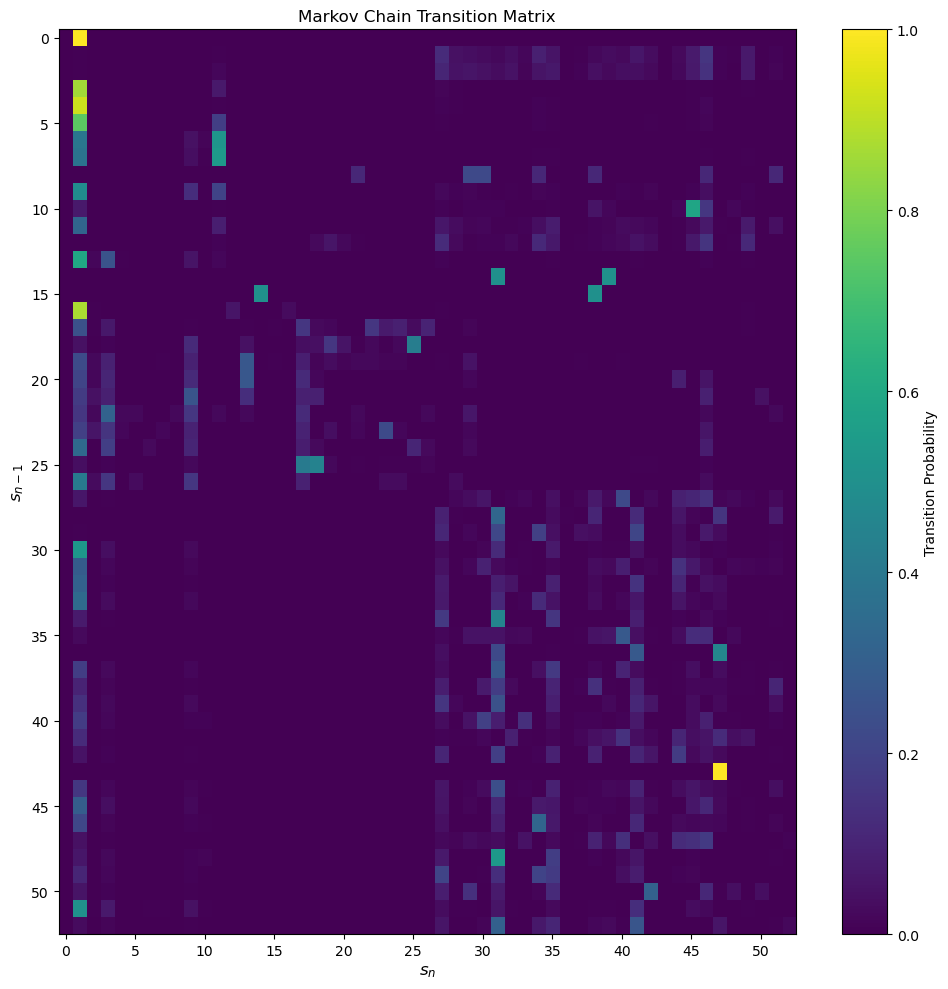

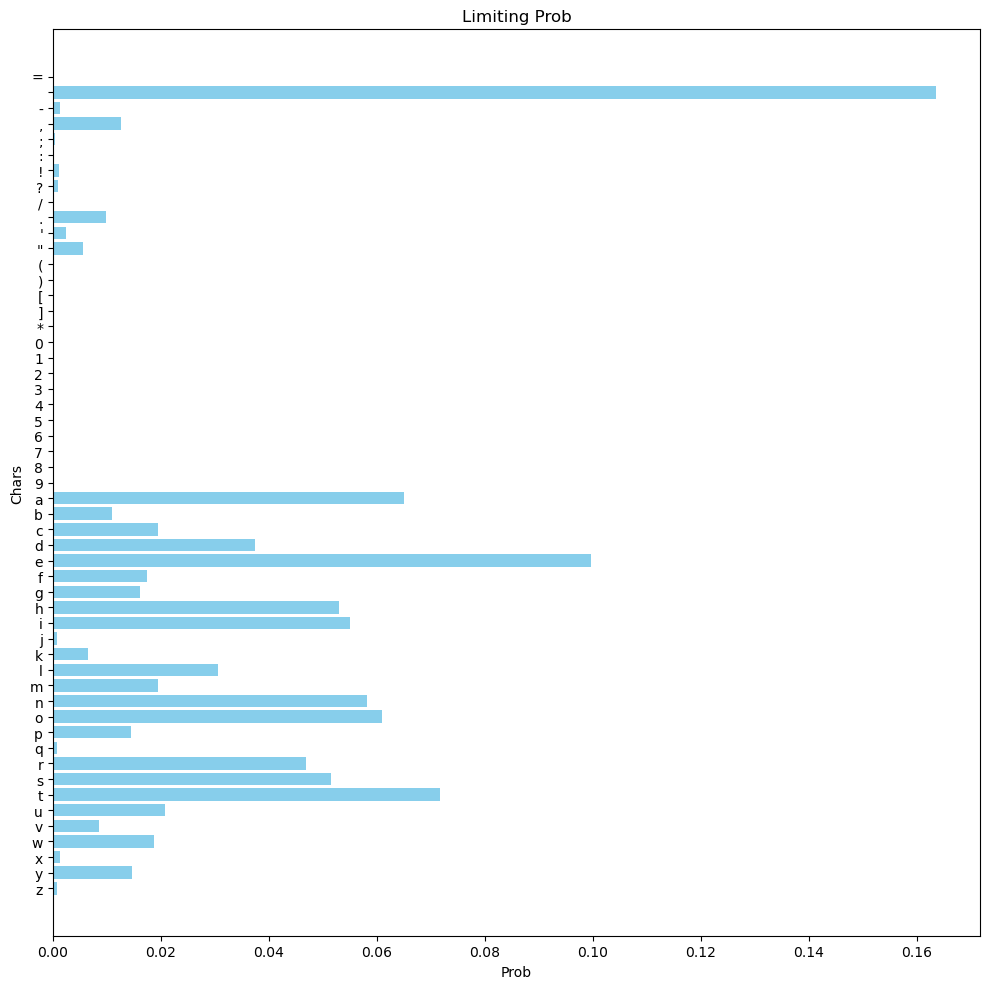

In [61]:
# latex_X_str = rf'X = \left[' + rf''.join(' '.join(X)) + r'\right] \\'
# latex_Psi_str = r'\Psi^* = \begin{bmatrix}' + \
#             r'\\'.join([' & '.join(['%.2g' % value for value in row]) for row in Psi]) + \
#             r'\end{bmatrix} \\'
# latex_pi_str = rf'\pi = \left[' + rf''.join(' , '.join(['%.2g' % value for value in limiting_prob])) + r'\right]'
# display(Math(latex_X_str + latex_Psi_str + latex_pi_str))
plt.figure(figsize=(10,10))
plt.imshow(Psi, interpolation='None', cmap='viridis', aspect='auto')
cbar = plt.colorbar()
cbar.set_label('Transition Probability')
plt.title('Markov Chain Transition Matrix')
plt.xlabel(r'$s_{n}$', fontsize=12)
plt.ylabel(r'$s_{n-1}$', fontsize=12)
num_states = Psi.shape[0]
tick_positions = np.arange(0, num_states, step=5)
plt.xticks(tick_positions)
plt.yticks(tick_positions)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))
plt.barh(X, limiting_prob, color='skyblue')
plt.ylabel('Chars')
plt.xlabel('Prob')
plt.title('Limiting Prob')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## (b) 

Consider a simple symbol space $\Omega = \{a, b\}$. We have permutation space that $\Omega_{\sigma}:=\{\sigma(a), \sigma(b)\} = \{a, b\}$. The mapping is bijective. Now we calculate 

\begin{align*}
p(\sigma(a) = b, \sigma(b) = a) &= p(\sigma(a) = b | \sigma(b) = a)p(\sigma(b) = a) \\
&= p(\sigma(b) = a)\\
&\neq p(\sigma(a) = b)p(\sigma(b)=a)
\end{align*}


So latent variables $\sigma(s)$ for different symbols $s$ are not independent.

If $e_i \in \Omega_{\sigma}$, then $\sigma^{-1}(e_i) \in \Omega$. So we have:
\begin{align*}
p(e_1e_2\dots e_n) &= p\left(\sigma^{-1}(e1)\sigma^{-1}(e2)\dots\sigma^{-1}(e_n)\right)\\
&=p\left(\sigma^{-1}(e_1)\right)\prod_{i=2}^np\left(\sigma^{-1}(e_i)|\sigma^{-1}(e_{i-1})\right)\\
&=\phi\left(\sigma^{-1}(e_1)\right)\prod_{i=2}^n\psi\left(\sigma^{-1}(e_i),\sigma^{-1}(e_{i-1})\right) \\
&=\phi_{c(\sigma^{-1}(e_1))} + \prod_{i=0}^{D-1}\prod_{j=0}^{D-1}\psi_{c(\sigma^{-1}(e_{i-1}))c(\sigma^{-1}(e_i))}^{m_{c(\sigma^{-1}(e_{i-1}))c(\sigma^{-1}(e_i))}}
\end{align*}
where $c: \Omega\rightarrow\mathbb{N}_0$ is an index mapping from symbol of English text to the index starting from 0.

## (c)
 

\begin{align*}
S(\sigma \rightarrow \sigma^\prime) &= \frac{2}{53 \times 52}\\
&= \frac{1}{1378}
\end{align*}

The 2 on the numerator comes from that we do not care the order of the 2 symbols.
The acceptance ratio is:
$$A(\sigma \rightarrow \sigma^\prime) = \min\left(1, \frac{S(\sigma^\prime \rightarrow \sigma)p(\sigma^\prime)}{S(\sigma \rightarrow \sigma^\prime)p(\sigma)}\right) = \min\left(1, \frac{p(\sigma^\prime)}{p(\sigma)}\right)$$

## (d)

In [363]:
# Metropolis-Hastings sampler for decrypting message
class MH_Sampler:

    def __init__(self, X, Psi, phi, Encrypted_data):
        """
        X: the original English text
        Psi: Markov Chain transition probability matrix for original English text
        phi: limiting probability vector for Psi
        Encrypted_data: A string of encrypted chars
        """
        self._X = X
        self._Psi = Psi
        self._phi = phi
        self._D = Psi.shape[0]
        self._data = Encrypted_data
        self._N = len(Encrypted_data)
        self._idx_mapping = dict(zip(range(self._D), X))
        self._inverse_idx_mapping = dict(zip(X, range(self._D)))
        # Here we record m_{c(e_{i-1})c(e_{i})}
        # later we can multiply it by an inverse permutation matrix to get the m_{c(\sigma^{-1}(e_{i-1}))c(\sigma^{-1}(e_{i}))}
        _M = np.zeros((self._D, self._D))
        for k in range(self._N - 1):
            i = self._inverse_idx_mapping[self._data[k]]
            j = self._inverse_idx_mapping[self._data[k+1]]
            _M[i,j] += 1
        self._M = _M
        self._M_non_zero_entry = np.argwhere(_M > 0)
        

    def sigma_mapping(self, permutation_list):
        """
        permutation_list: a permutation of symbols
        return sigma_map: from X to encrypted_list
               inverse_map: from encrypted_list to X
        """
        sigma = dict(zip(self._X, permutation_list))
        inverse_sigma = dict(zip(permutation_list, self._X))
        return sigma, inverse_sigma
    
    def log_joint(self, permutation_list):
        sigma, inverse_sigma = self.sigma_mapping(permutation_list)
        # first data
        log_p = np.log(self._phi[self._inverse_idx_mapping[inverse_sigma[self._data[0]]]]) 

        for entry in self._M_non_zero_entry:
            i , j = (entry[0], entry[1])
            x_i = self._idx_mapping[i]
            x_j = self._idx_mapping[j]
            original_i = self._inverse_idx_mapping[inverse_sigma[x_i]]
            original_j = self._inverse_idx_mapping[inverse_sigma[x_j]]
            m_ij = self._M[i, j]
            psi = self._Psi[original_i, original_j]
            # We have to protect from psi = 0, adding a floor
            log_p += m_ij * np.log(max(0.0001, psi))
        return log_p
    
    def mcmc_step(self, last_permutation):
        idx1, idx2 = np.random.choice(self._D, 2, replace=False)
        new_permutation = copy.deepcopy(last_permutation)
        new_permutation[[idx1, idx2]] = new_permutation[[idx2, idx1]]
        old_log = self.log_joint(last_permutation)
        new_log = self.log_joint(new_permutation)
        acceptance_ratio = min(0.0, new_log - old_log)
        accepted = np.log(np.random.rand(1)[0]) < acceptance_ratio
        if accepted:
            return new_permutation, accepted
        else:
            return last_permutation, accepted
        
    def run_mcmc(self, N_iters, init_permutation):
        this_permutation = init_permutation
        Naccepted = 0
        for _ in range(N_iters):
            this_permutation, accepted = self.mcmc_step(this_permutation)
            Naccepted += int(accepted)
        return this_permutation, Naccepted / N_iters
    
    def decrypt_message(self, permuation, data):
        sigma, inverse_sigma = self.sigma_mapping(permuation)
        message = ''.join([inverse_sigma[d] for d in data])
        return message

    

In [287]:
with open('message.txt', 'r') as file:
    message = file.read()
message = np.array(list(message))

For initial guess, we first calcuate the frequency of the characters in message.txt and sort the characters. We map the sorted characters to those with sorted limiting probability in Markov Chain.

This can be a starting point. We also find the first 20 characters in frequency list have 0 frequency. Shuffling between them will not change the log likelihood. We choose to shuffle 30th to 45th ones and calculate the log likelihood, choose the largest one as the initial point. We do not want to shuffle the last characters with highest frequencies as they are almost certainly the ones mapped (such as space, 'e', ...).

In [373]:
sampler = MH_Sampler(X, Psi, limiting_prob, message)

sorted_limit_prob, sorted_X = zip(*sorted(zip(limiting_prob, X)))
sorted_limit_prob = np.array(sorted_limit_prob)
sorted_X = np.array(sorted_X)

freqs = np.zeros(D)
for k in range(len(message)):
    freqs[X_map[message[k]]] += 1
sorted_freqs, sorted_guess = zip(*sorted(zip(freqs, X)))
sorted_freqs = np.array(sorted_freqs)
print(sorted_freqs[:20])
print("First 20 characters are not in message.")
sorted_guess = np.array(sorted_guess)

init_map = dict(zip(sorted_X, sorted_guess))
init_guess = np.array([init_map[x] for x in X])
log_p = sampler.log_joint(init_guess)

# We need to choose init permutation smartly so that no psi is 0
perms = [init_guess]
log_ps = [log_p]

np.random.seed(5)
for _ in range(3000):
    np.random.shuffle(sorted_guess[30:45])
    this_map = dict(zip(sorted_X, sorted_guess))
    this_perm = np.array([this_map[x] for x in X])
    this_log_p = sampler.log_joint(this_perm)
    perms.append(this_perm)
    log_ps.append(this_log_p)
# We pick the largest log likelihood as initial guess
idx = np.argmax(np.array(log_ps))
print(log_ps[idx])
init_perm = perms[idx]
    

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 20 characters are not in message.
-5151.979358765053


In [372]:
num_each_rep = 100
reps = 100
new_permutation = copy.deepcopy(init_perm)
for _ in range(reps):
    new_permutation, accepted_rate = sampler.run_mcmc(num_each_rep, new_permutation)
    print(sampler.decrypt_message(new_permutation, message[:60]))


on yu ughn.es tnd ygse phrnestbre uetsi yu ftaces .tpe ye ig
on yu ugin.es tnd ygse pirnestbre uetsl yu wtaces .tpe ye lg
on yg gutn.es ind yuse vtrnesibre geisl yg wiaces .ive ye lu
in bg gutn.es ond buse vtrnesoyre geosl bg woaces .ove be lu
in bg gutn.es ond buse vtrnesoyre geosl bg woaces .ove be lu
in bg gutn.es ond buse vtrnesoyre geosl bg woaces .ove be lu
in pg gutn.es ond puse vtrnesoyre geosl pg woaces .ove pe lu
in pw wutn.es ond puse vtrnesoyre weosl pw goaces .ove pe lu
in pw wutn.es ond puse vtrnesokre weosl pw goaces .ove pe lu
in pw watn.es ond pase vtrnesokre weosl pw gouces .ove pe la
in pk katn.es ond pase vtrnesowre keosl pk gofces .ove pe la
in pk katn.es ond pase vtrnesofre keosl pk gowhes .ove pe la
in pk katn.el ond pale vtrnelofre keols pk gowhel .ove pe sa
in pk katn.el ond pale vtrnelofre keols pk gowhel .ove pe sa
in py yawnkel ond pale vwrnelofre yeols py gothel kove pe sa
in py yawnkel ond pale vwrnelofre yeols py gothel kove pe sa
in py yawnkel ond pale v

## (e) 

We can plot a graph with node being the state and edge being the possible communication between the states ($\psi_{ij} > 0$). We can see this Markov Chain is irreducible. Finite irreducible Markov Chain is positive recurrent and all irreducible states have the same periodicity. We can see $\psi_{ii} > 0$ for some $i$, which means the periodicity is 1. Therefore this Markov Chain is aperiodic. As a result, it is ergodic.

Having said that, when running MCMC we are very likely entering into the state where the transition probability is 0, making $\log$ calculation fail. We add a tiny amount ($10^{-4}$) to get MCMC run without $-\inf$ issue.

## (f) 

- No, symbol probabilities alone are not sufficient. You may refer to my methodology of choosing the initial guess. For some characters, the frequency is 0 which means they did not appear in the message. We have to infer them from other characters appeared. Since the variables are not independent, we can do that. Even though we have all the characters in the training message, it does not take order of characters into account.
- For second order Markov Chain, the transition matrix will be a $D\times D\times D$ cube, which will be very sparse, i.e. many entries will be 0. This could cause the Markov Chain not irreducible anymore, which will result limiting probability not existing. Running MCMC will not converge if we do not have stationary density.
- Bijiction is key in the algorithm. If not, we cannot calculate $\sigma^{-1}(e_i)$.
- This will have similar issue as second order Markov Chain. The transition matrix could be huge and sparse, resulting reducible Markov Chain and non-existent limiting probability. Even though we are lucky enough to have an irreducible and ergodic Markov Chain, we need huge amount of data to run the algorithm and MCMC convergence will be extremely slow.

# Q6

## (a)

We copy the code from `gibbs_sampler.py` here and modify it.

In [62]:
# -*- coding: utf-8 -*-

"""
    File name: gibbs_sampler.py
    Description: a re-implementation of the Gibbs sampler for http://www.gatsby.ucl.ac.uk/teaching/courses/ml1
    Author: python: Roman Pogodin, MATLAB (original): Yee Whye Teh and Maneesh Sahani
    Date created: October 2018
    Python version: 3.6
"""

import numpy as np
import pandas as pd
from scipy.special import gammaln
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=2)


# todo: sample everything from self.rang_gen to control the random seed (works as numpy.random)
class GibbsSampler:
    def __init__(self, n_docs, n_topics, n_words, alpha, beta, random_seed=None):
        """
        :param n_docs:          number of documents
        :param n_topics:        number of topics
        :param n_words:         number of words in vocabulary
        :param alpha:           dirichlet parameter on topic mixing proportions
        :param beta:            dirichlet parameter on topic word distributions
        :param random_seed:     random seed of the sampler
        """
        self.n_docs = n_docs
        self.n_topics = n_topics
        self.n_words = n_words
        self.alpha = alpha
        self.beta = beta
        self.rand_gen = np.random.RandomState(random_seed)

        self.docs_words = np.zeros((self.n_docs, self.n_words))
        self.docs_words_test = None
        self.loglike = None
        self.loglike_test = None
        self.do_test = False

        self.A_dk = np.zeros((self.n_docs, self.n_topics))  # number of words in document d assigned to topic k
        self.B_kw = np.zeros((self.n_topics, self.n_words))  # number of occurrences of word w assigned to topic k
        self.A_dk_test = np.zeros((self.n_docs, self.n_topics))
        self.B_kw_test = np.zeros((self.n_topics, self.n_words))

        self.theta = np.ones((self.n_docs, self.n_topics)
                             ) / self.n_topics  # theta[d] is the distribution over topics in document d
        self.phi = np.ones((self.n_topics, self.n_words)) / self.n_words  # phi[k] is the distribution words in topic k

        self.topics_space = np.arange(self.n_topics)
        self.topic_doc_words_distr = np.zeros((self.n_topics, self.n_docs, self.n_words))  # z_id|x_id, theta, phi

    def init_sampling(self, docs_words, docs_words_test=None,
                      theta=None, phi=None, n_iter=0, save_loglike=False):
        assert np.all(docs_words.shape == (self.n_docs, self.n_words)), "docs_words shape=%s must be (%d, %d)" % (
            docs_words.shape, self.n_docs, self.n_words)
        self.n_docs = docs_words.shape[0]

        self.docs_words = docs_words
        self.docs_words_test = docs_words_test

        self.do_test = (docs_words_test is not None)

        if save_loglike:
            self.loglike = np.zeros(n_iter)

            if self.do_test:
                self.loglike_test = np.zeros(n_iter)

        self.A_dk.fill(0.0)
        self.B_kw.fill(0.0)
        self.A_dk_test.fill(0.0)
        self.B_kw_test.fill(0.0)

        self.init_params(theta, phi)

    def init_params(self, theta=None, phi=None):
        if theta is None:
            self.theta = np.ones((self.n_docs, self.n_topics)) / self.n_topics
        else:
            self.theta = theta.copy()

        if phi is None:
            self.phi = np.ones((self.n_topics, self.n_words)) / self.n_words
        else:
            self.phi = phi.copy()

        self.update_topic_doc_words()
        self.sample_counts()

    def run(self, docs_words, docs_words_test=None,
            n_iter=100, theta=None, phi=None, save_loglike=False):
        """
        docs_words is a matrix n_docs * n_words; each entry
        is a number of occurrences of a word in a document
        docs_words_test does not influence the updates and is used
        for validation
        """
        self.init_sampling(docs_words, docs_words_test,
                           theta, phi, n_iter, save_loglike)

        for iteration in range(n_iter):
            self.update_params()

            if save_loglike:
                self.update_loglike(iteration)

        return self.to_return_from_run()

    def to_return_from_run(self):
        return self.topic_doc_words_distr, self.theta, self.phi

    def update_params(self):
        """
        Samples theta and phi, then computes the distribution of
        z_id and samples counts A_dk, B_kw from it
        """
        # todo: sample theta and phi
        self.theta = np.array([self.rand_gen.dirichlet(self.A_dk[d, :] + self.alpha) for d in range(self.n_docs)])
        self.phi = np.array([self.rand_gen.dirichlet(self.B_kw[k, :] + self.beta) for k in range(self.n_topics)])

        self.update_topic_doc_words()
        self.sample_counts()

    def update_topic_doc_words(self):
        """
        Computes the distribution of z_id|x_id, theta, phi
        """
        self.topic_doc_words_distr = np.repeat(
            self.theta.T[:, :, None], self.n_words, axis=2) * self.phi[:, None, :]
        self.topic_doc_words_distr /= self.theta.dot(self.phi)[None, :, :]

    def sample_counts(self):
        """
        For each document and each word, samples from z_id|x_id, theta, phi
        and adds the results to the counts A_dk and B_kw
        """
        self.A_dk.fill(0)
        self.B_kw.fill(0)

        if self.do_test:
            self.A_dk_test.fill(0)
            self.B_kw_test.fill(0)

        # todo: sample a topic for each (doc, word) and update A_dk, B_kw correspondingly
        for d in range(self.n_docs):
            for w in range(self.n_words):
                if self.do_test:
                    additional_samples = self.docs_words_test[d, w]
                else:
                    additional_samples = 0
                pr_z_dw = self.topic_doc_words_distr[:, d, w]
                sampled_topics = self.rand_gen.choice(self.topics_space, self.docs_words[d, w] + additional_samples, p = pr_z_dw)
                sampled_topics_train = sampled_topics[:self.docs_words[d, w]]
                sample, counts = np.unique(sampled_topics_train, return_counts=True)
                self.A_dk[d, sample] += counts
                self.B_kw[sample, w] += counts
                if self.do_test:
                    sampled_topics_test = sampled_topics[self.docs_words[d, w]:]
                    sample, counts = np.unique(sampled_topics_test, return_counts=True)
                    self.A_dk_test[d, sample] += counts
                    self.B_kw_test[sample, w] += counts
        

    def update_loglike(self, iteration):
        """
        Updates loglike of the data, omitting the constant additive term
        with Gamma functions of hyperparameters
        """
        # todo: implement log-like
        # Hint: use scipy.special.gammaln (imported as gammaln) for log(gamma)
        log_gamma_Adk_alpha = gammaln(self.A_dk + self.alpha)
        log_gamma_Bkw_beta = gammaln(self.B_kw + self.beta)
        M_k = np.sum(self.B_kw, axis=1)
        N_d = np.sum(self.A_dk, axis=1)
        log_gamma_Mk_Wbeta = gammaln(M_k + self.n_words * self.beta)
        log_gamma_Nd_Kalpha = gammaln(N_d + self.n_topics * self.alpha)
        this_loglike = np.sum(log_gamma_Bkw_beta) - np.sum(log_gamma_Mk_Wbeta) + np.sum(log_gamma_Adk_alpha) - np.sum(log_gamma_Nd_Kalpha)
        self.loglike[iteration] = this_loglike
        if self.do_test:
            log_gamma_Adk_alpha_test = gammaln(self.A_dk_test + self.alpha)
            log_gamma_Bkw_beta_test = gammaln(self.B_kw_test + self.beta)
            M_k_test = np.sum(self.B_kw_test, axis=1)
            N_d_test = np.sum(self.A_dk_test, axis=1)
            log_gamma_Mk_Wbeta_test = gammaln(M_k_test + self.n_words * self.beta)
            log_gamma_Nd_Kalpha_test = gammaln(N_d_test + self.n_topics * self.alpha)
            this_loglike_test = np.sum(log_gamma_Bkw_beta_test) - np.sum(log_gamma_Mk_Wbeta_test) + np.sum(log_gamma_Adk_alpha_test) - np.sum(log_gamma_Nd_Kalpha_test)
            self.loglike_test[iteration] = this_loglike_test

    def get_loglike(self):
        """Returns log-likelihood at each iteration."""
        if self.do_test:
            return self.loglike, self.loglike_test
        else:
            return self.loglike


class GibbsSamplerCollapsed(GibbsSampler):
    def __init__(self, n_docs, n_topics, n_words, alpha, beta, random_seed=None):
        """
        :param n_docs:          number of documents
        :param n_topics:        number of topics
        :param n_words:         number of words in vocabulary
        :param alpha:           dirichlet parameter on topic mixing proportions
        :param beta:            dirichlet parameter on topic word distributions
        :param random_seed:     random seed of the sampler
        """
        super().__init__(n_docs, n_topics, n_words, alpha, beta, random_seed)

        # topics assigned to each (doc, word)
        self.doc_word_samples = np.ndarray((self.n_docs, self.n_words), dtype=object)
        self.doc_word_samples_test = self.doc_word_samples.copy()

    def init_params(self, theta=None, phi=None):
        # z_id are initialized uniformly
        for doc in range(self.n_docs):
            for word in range(self.n_words):
                if self.do_test:
                    additional_samples = self.docs_words_test[doc, word]
                else:
                    additional_samples = 0

                sampled_topics = self.rand_gen.choice(self.topics_space,
                                                      size=self.docs_words[doc, word] + additional_samples)

                sampled_topics_train = sampled_topics[:self.docs_words[doc, word]]
                self.doc_word_samples[doc, word] = sampled_topics_train.copy()  # now each cell is an np.array

                sample, counts = np.unique(sampled_topics_train, return_counts=True)

                self.A_dk[doc, sample] += counts
                self.B_kw[sample, word] += counts

                if self.do_test:
                    sampled_topics_test = sampled_topics[self.docs_words[doc, word]:]
                    self.doc_word_samples_test[doc, word] = sampled_topics_test.copy()

                    sample, counts = np.unique(sampled_topics_test, return_counts=True)

                    self.A_dk_test[doc, sample] += counts
                    self.B_kw_test[sample, word] += counts

    def update_params(self):
        """
        Computes the distribution of z_id.
        Sampling of A_dk, B_kw is done automatically as
        each new z_id updates these counters
        """
        # todo: sample a topic for each (doc, word) and update A_dk, B_kw correspondingly
        # Hint: you can update A_dk, B_kw after each sampling instead of re-computing the whole matrix
        for d in range(self.n_docs):
            for w in range(self.n_words):
                for i in range(len(self.doc_word_samples[d, w])):
                    old_topic = self.doc_word_samples[d, w][i]
                    self.A_dk[d, old_topic] -= 1
                    self.B_kw[old_topic, w] -= 1
                    p_zid = (self.A_dk[d, :] + self.alpha) * (self.B_kw[:, w] + self.beta) / (np.sum(self.B_kw, axis=1) + self.n_words * self.beta)
                    p_zid /= np.sum(p_zid)
                    sampled_topic = self.rand_gen.choice(self.topics_space, 1, p=p_zid)[0]
                    self.doc_word_samples[d, w][i] = sampled_topic
                    self.A_dk[d, sampled_topic] += 1
                    self.B_kw[sampled_topic, w] += 1

                if self.do_test:
                    for i in range(len(self.doc_word_samples_test[d, w])):
                        old_topic = self.doc_word_samples_test[d, w][i]
                        self.A_dk_test[d, old_topic] -= 1
                        self.B_kw_test[old_topic, w] -= 1
                        p_zid_test = (self.A_dk_test[d, :] + self.alpha) * (self.B_kw_test[:, w] + self.beta) / (np.sum(self.B_kw_test, axis=1) + self.n_words * self.beta)
                        p_zid_test /= np.sum(p_zid_test)
                        sampled_topic_test = self.rand_gen.choice(self.topics_space, 1, p=p_zid_test)[0]
                        self.doc_word_samples_test[d, w][i] = sampled_topic_test
                        self.A_dk_test[d, sampled_topic_test] += 1
                        self.B_kw_test[sampled_topic_test, w] += 1

    def update_loglike(self, iteration):
        """
        Updates loglike of the data, omitting the constant additive term
        with Gamma functions of hyperparameters
        """
        # todo: implement log-like
        super().update_loglike(iteration)

    def to_return_from_run(self):
        return self.doc_word_samples


def read_data(filename):
    """
    Reads the text data and splits into train/test.
    Examples:
    docs_words_train, docs_words_test = read_data('./code/toyexample.data')
    nips_train, nips_test = read_data('./code/nips.data')
    :param filename:    path to the file
    :return:
    docs_words_train:   training data, [n_docs, n_words] numpy array
    docs_words_test:    test data, [n_docs, n_words] numpy array
    """
    data = pd.read_csv(filename, dtype=int, sep=' ', names=['doc', 'word', 'train', 'test'])

    n_docs = np.amax(data.loc[:, 'doc'])
    n_words = np.amax(data.loc[:, 'word'])

    docs_words_train = np.zeros((n_docs, n_words), dtype=int)
    docs_words_test = np.zeros((n_docs, n_words), dtype=int)

    docs_words_train[data.loc[:, 'doc'] - 1, data.loc[:, 'word'] - 1] = data.loc[:, 'train']
    docs_words_test[data.loc[:, 'doc'] - 1, data.loc[:, 'word'] - 1] = data.loc[:, 'test']

    return docs_words_train, docs_words_test

In [63]:
def run_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test=None, iteration=200, show_plot=True):
    print('Running with the standard sampler')
    sampler = GibbsSampler(n_docs=n_docs, n_topics=n_topics, n_words=n_words,
                            alpha=alpha, beta=beta, random_seed=random_seed)

    topic_doc_words_distr, theta, phi = sampler.run(docs_words_train, docs_words_test,
                                                    n_iter=iteration, save_loglike=True)

    print(phi * [phi > 1e-2])

    like_train, like_test = sampler.get_loglike()

    if show_plot:
        plt.subplots(figsize=(15, 6))
        plt.plot(like_train, label='train')
        plt.plot(like_test, label='test')

        plt.ylabel('loglike')
        plt.xlabel('iteration')
        plt.legend()
        plt.show()
    
    return topic_doc_words_distr, theta, phi, like_train, like_test

def run_Collapsed_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test=None, iteration=200, show_plot=True):
    print('Running with the collapsed sampler')

    sampler_collapsed = GibbsSamplerCollapsed(n_docs=n_docs, n_topics=n_topics, n_words=n_words,
                                                alpha=alpha, beta=beta, random_seed=random_seed)

    doc_word_samples = sampler_collapsed.run(docs_words_train, docs_words_test,
                                                n_iter=iteration, save_loglike=True)
    topic_counts = np.zeros((n_topics, n_words))
    for doc in range(doc_word_samples.shape[0]):
        for word in range(doc_word_samples.shape[1]):
            for topic in doc_word_samples[doc, word]:
                topic_counts[topic, word] += 1

    print(topic_counts)

    like_train, like_test = sampler_collapsed.get_loglike()

    if show_plot:
        plt.subplots(figsize=(15, 6))
        plt.plot(like_train, label='train')
        plt.plot(like_test, label='test')

        plt.ylabel('loglike')
        plt.xlabel('iteration')
        plt.legend()
        plt.show()
    return doc_word_samples, like_train, like_test

In [64]:
docs_words_train, docs_words_test = read_data('./toyexample.data')
n_docs, n_words = docs_words_train.shape
n_topics = 3
alpha = 1
beta = 1
random_seed = 0

Running with the standard sampler
[[[0.46214235 0.31674823 0.01920462 0.07022256 0.09657532 0.03510691]
  [0.         0.04377234 0.43726295 0.48205206 0.01111043 0.01649975]
  [0.02822529 0.         0.02830697 0.03466354 0.33396917 0.57296207]]]


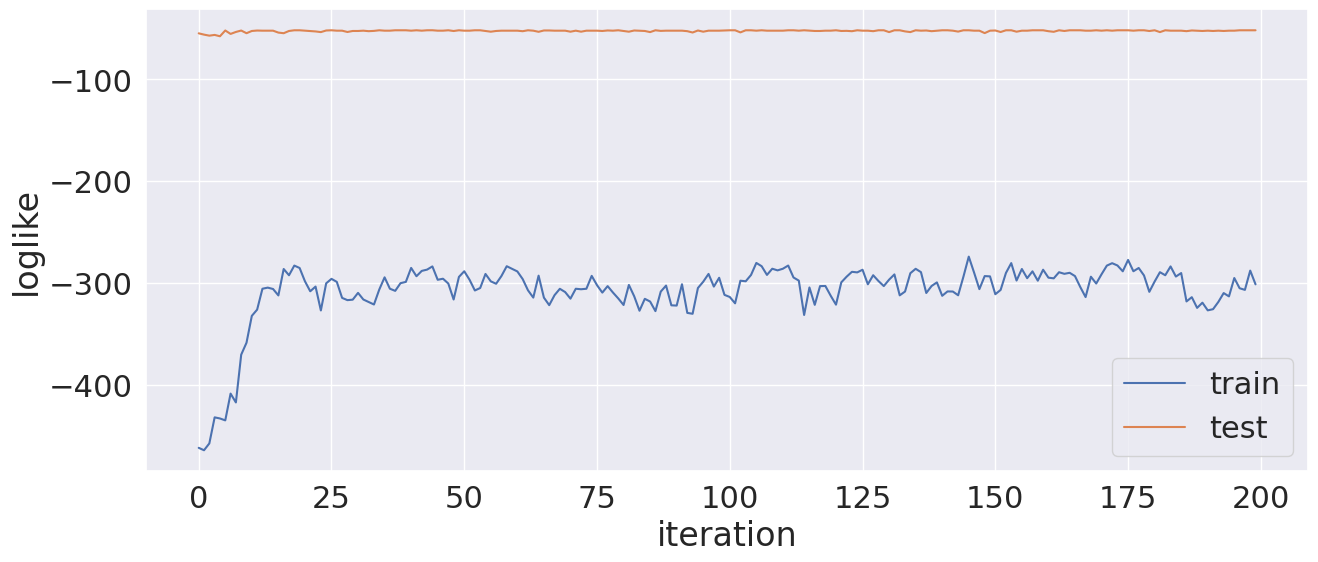

Running with the collapsed sampler
[[ 2.  0.  0.  0. 24. 25.]
 [ 0.  0. 24. 19.  1.  0.]
 [23. 25.  1.  6.  0.  0.]]


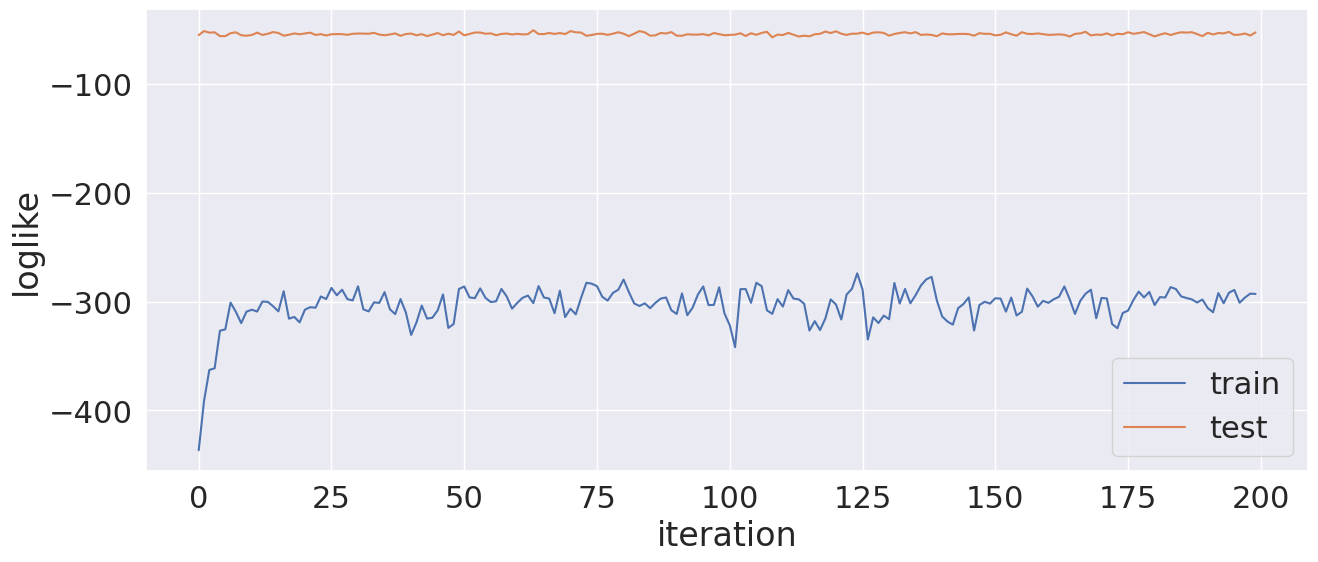

In [65]:
topic_doc_words_distr, theta, phi, like_train_gibbs, like_test_gibbs = run_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test)
doc_word_samples, like_train_collapsed, like_test_collapsed = run_Collapsed_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test)

## (b)

We can use 25 as burn-in. We run 1000 times for `GibbsSampler` and `GibbsSamplerCollapsed`, drop first 25 iterations, compute and plot autocorrelations for log predictive and log joint. For log joint, the autocorrelation decreases to around 0 since lag 4 in `GibbsSampler` but since lag 2 for `GibbsSamplerCollasped`. For log predict, it is around 0 since lag 1 for `GibbsSampler` and since lag 2 for `GibbsSamplerCollasped`. We can pick every 4 point in the `GibbsSampler` (lag = 4) and every other point in `GibbsSamplerCollasped` (lag = 2). If we need 2000 samples for each posterior, we have to simulate 8000 and 4000 iterations after burn-in respectively.

In [66]:
NBurntIn = 25
topic_doc_words_distr, theta, phi, like_joint, like_predict = run_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test, 1000, False)
burnt_in_joint, burnt_in_predict = like_joint[NBurntIn:], like_predict[NBurntIn:]

doc_word_samples, like_collapsed_joint, like_collaspes_predict = run_Collapsed_GibbsSampler(n_docs, n_topics, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test, 1000, False)
burnt_in_collasped_joint, burnt_in_collapsed_predict = like_collapsed_joint[NBurntIn:], like_collaspes_predict[NBurntIn:]

Running with the standard sampler
[[[0.49612631 0.25791605 0.15328706 0.02101735 0.0187987  0.05285452]
  [0.0124196  0.02777288 0.38699126 0.52193608 0.         0.04140046]
  [0.04694453 0.07128145 0.05596845 0.01386746 0.37863034 0.43330777]]]
Running with the collapsed sampler
[[ 2.  1.  0.  1. 24. 24.]
 [ 6.  2. 24. 22.  1.  0.]
 [17. 22.  1.  2.  0.  1.]]


In [67]:
from statsmodels.graphics.tsaplots import plot_pacf
def plot_acf_gibbs(joint, predict, collasped_joint, collasped_predict):
    fig, ax = plt.subplots(2, 2, figsize=(12, 12))
    plot_pacf(joint, lags=10, ax=ax[0,0])
    ax[0,0].set_title('Autocorrelation for log joint in Gibbs Sampler', fontsize=12)
    ax[0,0].set_xlabel('Lags', fontsize=10)
    ax[0,0].set_ylabel('Correlation', fontsize=10)
    ax[0,0].tick_params(axis='x', labelsize=8)
    ax[0,0].tick_params(axis='y', labelsize=8)

    plot_pacf(predict, lags=10, ax=ax[0,1])
    ax[0,1].set_title('Autocorrelation for log predict in Gibbs Sampler', fontsize=12)
    ax[0,1].set_xlabel('Lags', fontsize=10)
    ax[0,1].set_ylabel('Correlation', fontsize=10)
    ax[0,1].tick_params(axis='x', labelsize=8)
    ax[0,1].tick_params(axis='y', labelsize=8)

    plot_pacf(collasped_joint, lags=10, ax=ax[1,0])
    ax[1,0].set_title('Autocorrelation for log joint in Collapsed Gibbs Sampler', fontsize=12)
    ax[1,0].set_xlabel('Lags', fontsize=10)
    ax[1,0].set_ylabel('Correlation', fontsize=10)
    ax[1,0].tick_params(axis='x', labelsize=8)
    ax[1,0].tick_params(axis='y', labelsize=8)

    plot_pacf(collasped_predict, lags=10, ax=ax[1,1])
    ax[1,1].set_title('Autocorrelation for log predict in Collapsed Gibbs Sampler', fontsize=12)
    ax[1,1].set_xlabel('Lags', fontsize=10)
    ax[1,1].set_ylabel('Correlation', fontsize=10)
    ax[1,1].tick_params(axis='x', labelsize=8)
    ax[1,1].tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.show()

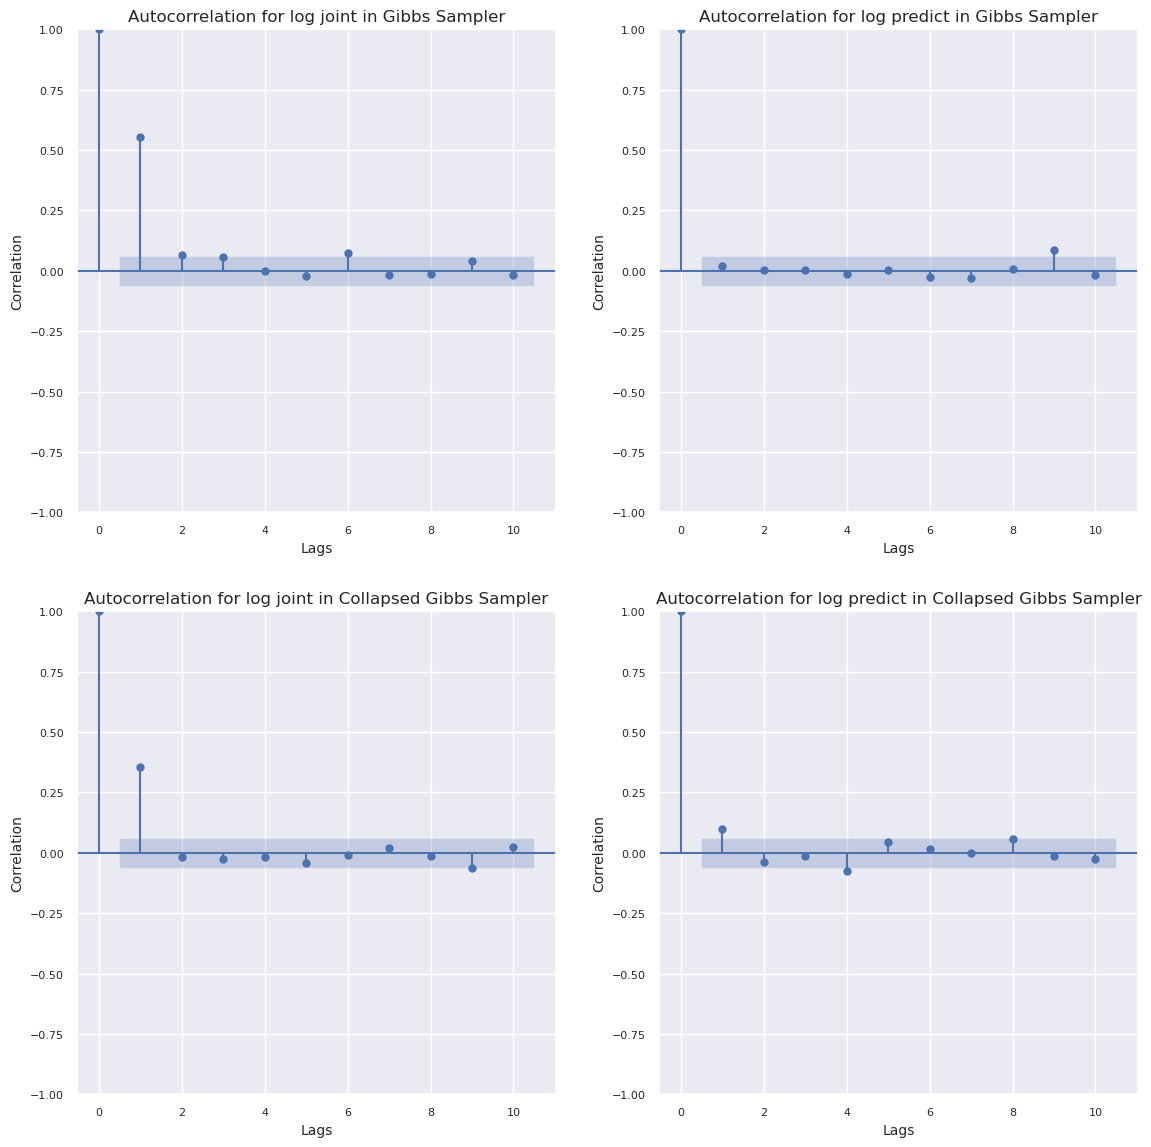

In [68]:
plot_acf_gibbs(burnt_in_joint, burnt_in_predict, burnt_in_collasped_joint, burnt_in_collapsed_predict)

## (c)

From autocorrelation plots and loglikelihoods plots versus iterations, we can see `GibbsSamplerCollapsed` converges faster then `GibbsSampler`. The reason why `GibbsSampler` converges faster are:
* We have fewer variables. Only $z_{id}$ are sampled instead of $z_{id}$ and ${x_{id}}$ in `GibbsSampler`
* This can reduce dimensionality and variance of sampling, making it converge faster
* The reduced dimensionality and variance also reduce autocorrelation, making the chain mix faster

## (d)

Larger $\alpha$ makes convergence slow for both samplers and much more volatile. Similar to $\beta$ and `n_topics`. These line with Dirichlet distribution that when $\alpha$ and $\beta$ are larger, the probabilities generated from Dirichlet distribution become more uniform because variance of Dirichlet is smaller. More uniform probabilities means the discrete distribution has larger variance (not concentrated). Alternatively speaking, a larger $\alpha$ implies that documents are expected to have a more uniform distribution over topics, meaning each document is likely to contain a mixture of many topics. A larger $\beta$ suggests topics are expected to have a more uniform distribution over words, so each topic covers a wider range of vocabulary. Both of them will increase randomness when larger, leading to higher sampling variance. Number of topics has similar effect. More topics will lead to more randomness and larger variance.

In [269]:
alphas = [0.5, 2]
betas = [0.5, 4]
n_topic_list = [2, 7]

In [ ]:
for alpha_ in alphas:
    _, __, ___, like_joint, like_predict = run_GibbsSampler(n_docs, n_topics, n_words, alpha_, beta, random_seed, docs_words_train, docs_words_test)
    _, like_joint_collapsed, like_predict_collapsed = run_Collapsed_GibbsSampler(n_docs, n_topics, n_words, alpha_, beta, random_seed, docs_words_train, docs_words_test)
    plot_acf_gibbs(like_joint[NBurntIn:], like_predict[NBurntIn:], like_joint_collapsed[NBurntIn:], like_predict_collapsed[NBurntIn:])

In [ ]:
for beta_ in betas:
    _, __, ___, like_joint, like_predict = run_GibbsSampler(n_docs, n_topics, n_words, alpha, beta_, random_seed, docs_words_train, docs_words_test)
    _, like_joint_collapsed, like_predict_collapsed = run_Collapsed_GibbsSampler(n_docs, n_topics, n_words, alpha, beta_, random_seed, docs_words_train, docs_words_test)
    plot_acf_gibbs(like_joint[NBurntIn:], like_predict[NBurntIn:], like_joint_collapsed[NBurntIn:], like_predict_collapsed[NBurntIn:])

In [ ]:
for this_n_topic in n_topic_list:
    _, __, ___, like_joint, like_predict = run_GibbsSampler(n_docs, this_n_topic, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test)
    _, like_joint_collapsed, like_predict_collapsed = run_Collapsed_GibbsSampler(n_docs, this_n_topic, n_words, alpha, beta, random_seed, docs_words_train, docs_words_test)
    plot_acf_gibbs(like_joint[NBurntIn:], like_predict[NBurntIn:], like_joint_collapsed[NBurntIn:], like_predict_collapsed[NBurntIn:])

## (e)


In [69]:
nips_words_train, nips_words_test = read_data('./nips.data')
tf = nips_words_train / np.sum(nips_words_train, axis=1)[:, None]
idf = np.log(nips_words_train.shape[0]/ (1 + np.count_nonzero(nips_words_train, axis=0)))
tf_idf = tf * idf[None, :]
# Sum over the docs
combined_tf_idf = np.sum(tf_idf, axis = 0)

In [70]:
tf_idf_sorted_idx = np.argsort(combined_tf_idf)
pruned_tf_idf_sorted_idx = tf_idf_sorted_idx[-200:]
pruned_tf_idf_sorted_idx = pruned_tf_idf_sorted_idx[::-1]
pruned_nips_words_train = nips_words_train[:100, pruned_tf_idf_sorted_idx]
pruned_nips_words_test = nips_words_test[:100, pruned_tf_idf_sorted_idx]

In [71]:
with open('./nips.vocab','r') as file:
    nips_words = np.array([line.strip() for line in file])

In [72]:
pruned_nips_words = nips_words[pruned_tf_idf_sorted_idx]
print(pruned_nips_words)

['neuron' 'cell' 'unit' 'training' 'learning' 'image' 'object' 'visual'
 'circuit' 'hidden' 'speech' 'weight' 'algorithm' 'layer' 'network'
 'classifier' 'chip' 'error' 'recognition' 'field' 'signal' 'model'
 'control' 'vector' 'distribution' 'noise' 'motion' 'pattern' 'gaussian'
 'spike' 'images' 'action' 'part' 'word' 'input' 'analog' 'data' 'bound'
 'output' 'neuroscience' 'map' 'memory' 'dynamic' 'filter' 'node' 'fig'
 'prediction' 'kernel' 'nodes' 'synaptic' 'policy' 'probability' 'matrix'
 'classification' 'net' 'class' 'expert' 'mixture' 'feature'
 'generalization' 'hmm' 'activity' 'recurrent' 'target' 'reinforcement'
 'tree' 'theorem' 'representation' 'equation' 'optimal' 'response'
 'connection' 'direction' 'task' 'gradient' 'stimulus' 'threshold'
 'cluster' 'correlation' 'activation' 'firing' 'method' 'approximation'
 'channel' 'likelihood' 'frequency' 'features' 'density' 'states'
 'component' 'eye' 'bayesian' 'phase' 'parameter' 'controller' 'region'
 'rate' 'linear' 'pixel

## (f)

We cut `n_words` to 200, `n_docs` to 100 and `n_topics` to 10 for demo provided with very slow simulation.

Running with the standard sampler
[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.15034108 0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.12843768 ... 0.         0.         0.        ]
  [0.25357967 0.         0.         ... 0.         0.         0.        ]]]


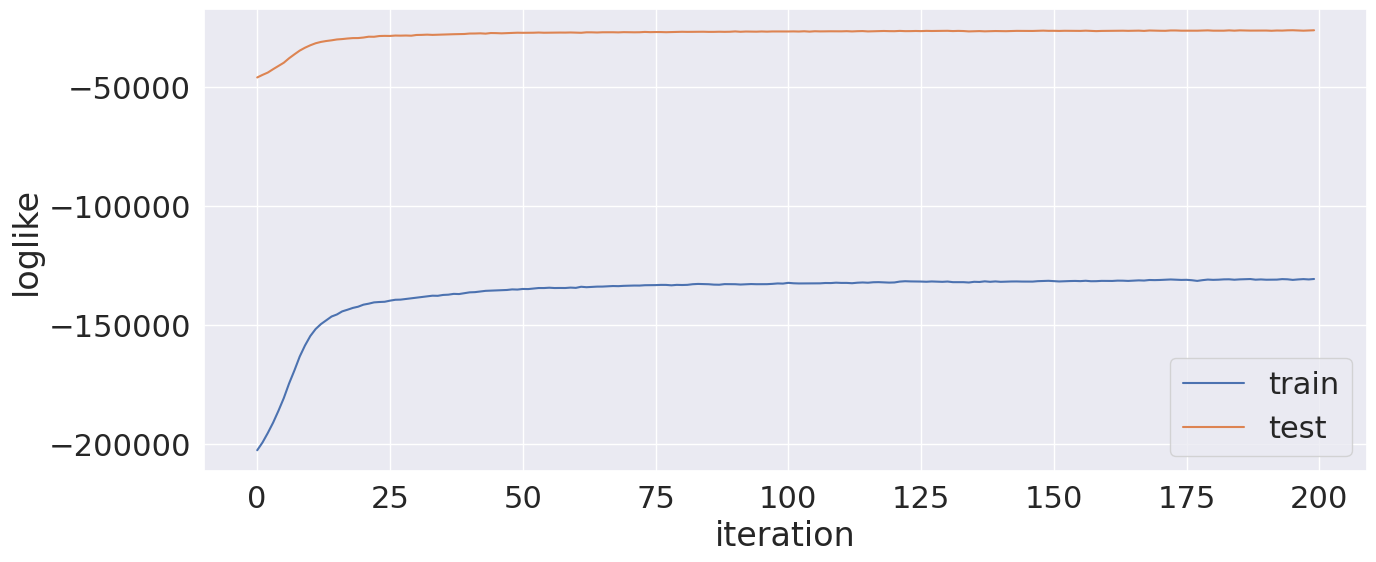

Running with the collapsed sampler
[[ 23.   0.   0. ...   0.   0.   0.]
 [  0.   0. 753. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.  20.]
 ...
 [  0.   0.   0. ...  10.  29.   0.]
 [  0.   0.   0. ...  15.   0.   0.]
 [  0.   0.   0. ...  13.   0.  36.]]


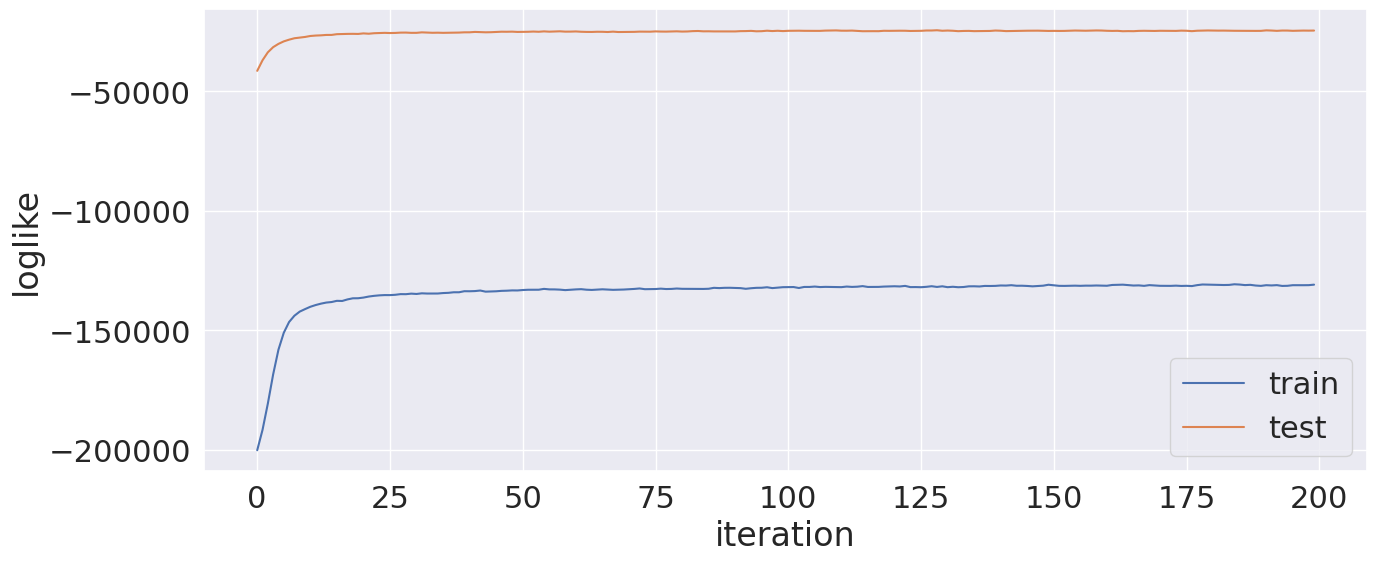

In [73]:
n_docs_nips, n_words_nips = pruned_nips_words_train.shape
n_topics_nips = 10
alpha_nips = 0.1
beta_nips = 0.01
random_seed = 10
topic_doc_words_distr, theta, phi, like_joint, like_predict = run_GibbsSampler(n_docs_nips, n_topics_nips, n_words_nips, alpha_nips, beta_nips, random_seed, pruned_nips_words_train, pruned_nips_words_test, 200)
doc_word_samples, like_collapsed_joint, like_collaspes_predict = run_Collapsed_GibbsSampler(n_docs_nips, n_topics_nips, n_words_nips, alpha_nips, beta_nips, random_seed, pruned_nips_words_train, pruned_nips_words_test, 200)

We use the sampled $\phi$ from `GibbsSampler` and use it as the frequency of words in each topic. We use it to plot the word cloud for visualisation.

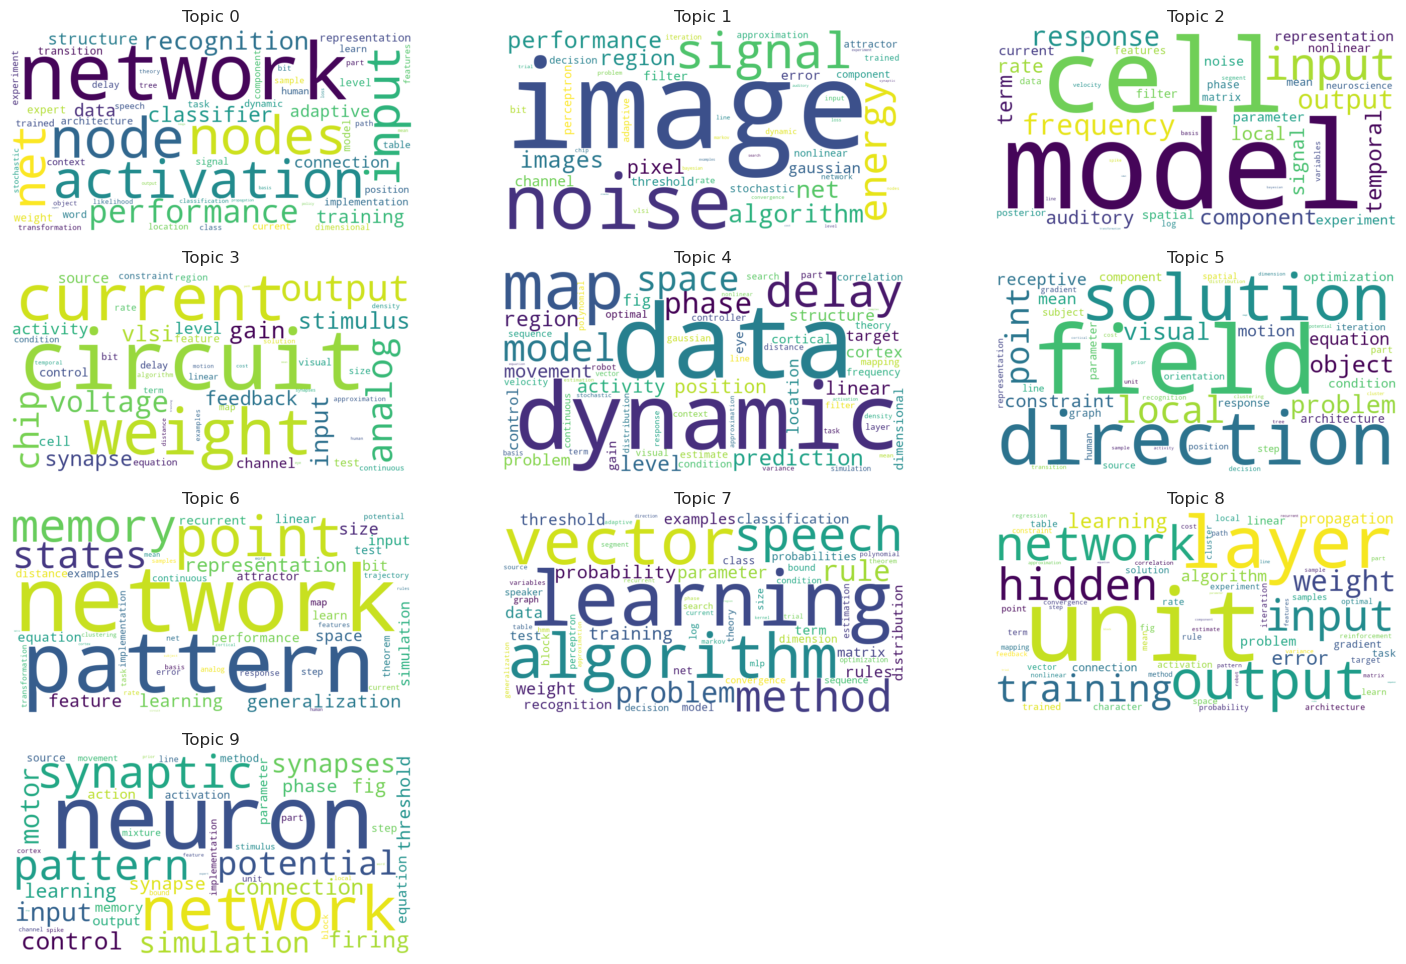

In [91]:
from wordcloud import WordCloud

rows = math.ceil(n_topics_nips / 3)
fig, axs = plt.subplots(rows, 3, figsize=(18,12))
axs = axs.flatten()
for k in range(n_topics_nips):
    word_freq = {pruned_nips_words[i]: phi[k, i] for i in range(n_words_nips)}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    axs[k].imshow(wordcloud, interpolation='bilinear')
    axs[k].axis('off')
    axs[k].set_title(f'Topic {k}', fontsize=12)

for i in range(n_topics_nips, len(axs)):
    fig.delaxes(axs[i])

We then use the sampled topic with words from `CollapsedGibbsSampler` and get the frequency in each topic and plot the word cloud as well.

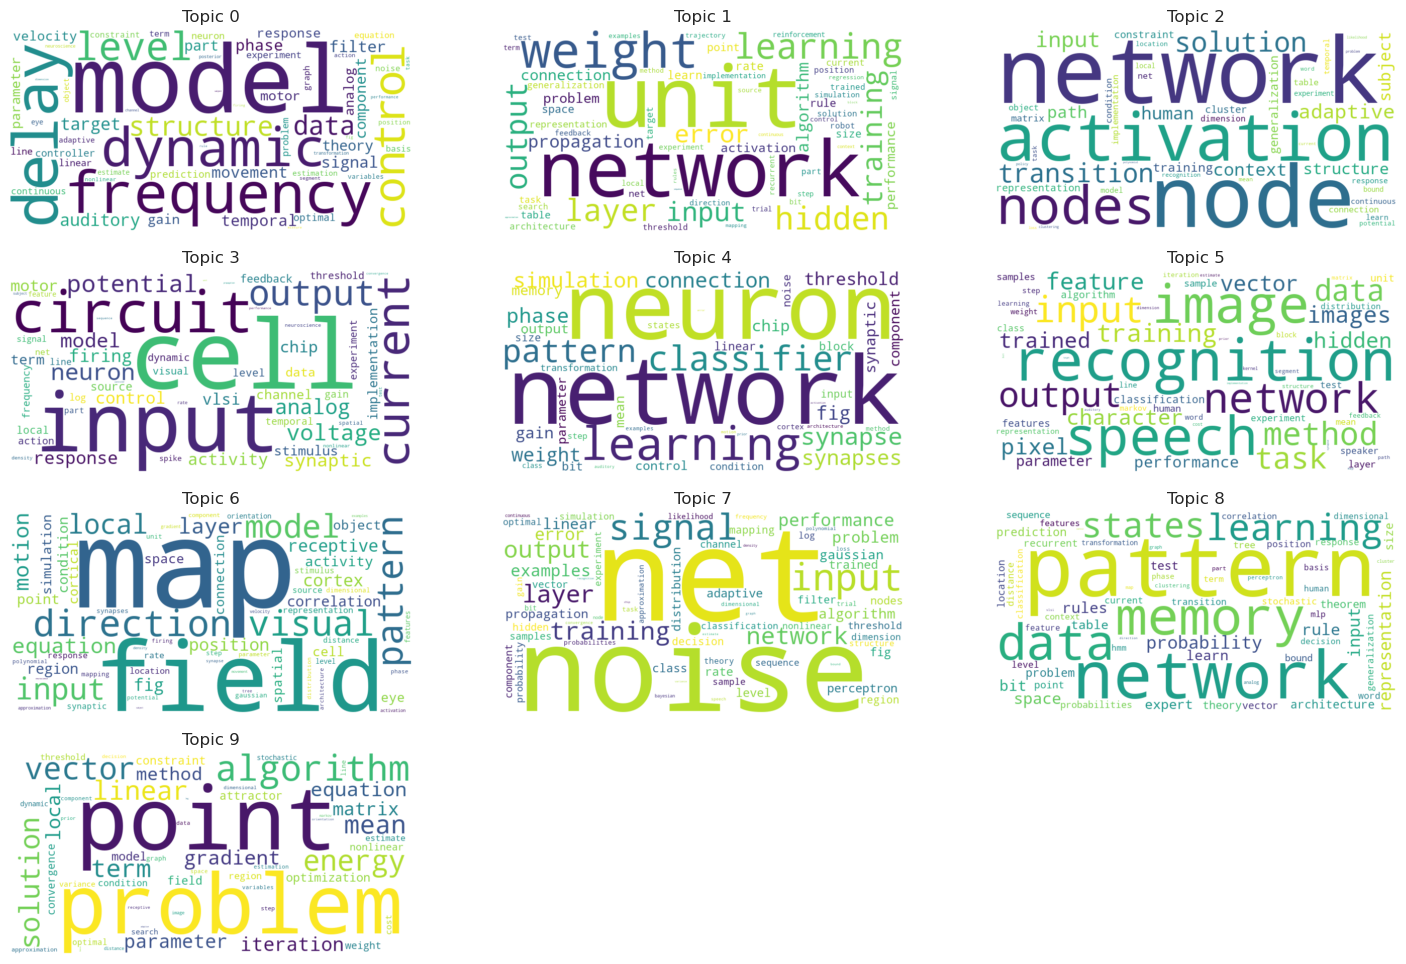

In [96]:
topic_sample_words = np.zeros((n_words_nips, n_topics_nips))
for doc in range(n_docs_nips):
    for word in range(n_words_nips):
        topic_sample = doc_word_samples[doc, word]
        sample, counts = np.unique(topic_sample, return_counts=True)
        topic_sample_words[word, sample] += counts
rows = math.ceil(n_topics_nips / 3)
fig, axs = plt.subplots(rows, 3, figsize=(18,12))
axs = axs.flatten()
for k in range(n_topics_nips):
    word_freq = {pruned_nips_words[i]: topic_sample_words[i, k] for i in range(n_words_nips)}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    axs[k].imshow(wordcloud, interpolation='bilinear')
    axs[k].axis('off')
    axs[k].set_title(f'Topic {k}', fontsize=12)

for i in range(n_topics_nips, len(axs)):
    fig.delaxes(axs[i])

Provided with slow simulation time, only one set of hyperparameters are shown.

# Q7

## (a) 

We set up Lagrange multiplier for $f(x, y)$ with constraint $g(x,y):=y^2 + xy - 1 = 0$.

\begin{align*}
F(x, y, \lambda) &= f(x, y) + \lambda g(x, y) \\
&=x+2y+\lambda(y^2+xy-1)
\end{align*}

Taking derivatives, set them to 0 and solve:

\begin{align*}
\frac{\partial F}{\partial x} &= 1 + \lambda y = 0 \\
\frac{\partial F}{\partial y} &= 2 + 2\lambda y+\lambda x = 0\\
\frac{\partial F}{\partial \lambda} &= y^2 + xy - 1 = 0
\end{align*}


We have 2 sets of points at which local extrema occur.

These are the points where local minimum occur.

\begin{align*}
x^* &= 0 \\
y^* &= -1 \\
\lambda^* &= 1
\end{align*}


These are the points where local maximum occur.

\begin{align*}
x^* &= 0 \\
y^* &= 1 \\
\lambda^* &= -1
\end{align*}


## (b) 

The root of $\exp(x) - a$ is $\ln(a)$. So we can set $f(x, a) := \exp(x) - a$ and use Newton-Raphson method to get the root.

The iteration is $$x_{n+1} = x_{n} - \frac{f(x_n, a)}{f^\prime(x_n, a)} = x_{n} - \frac{\exp(x_n)-a}{\exp(x_n)}$$
where $f^\prime(x_n, a) = \frac{\partial f}{\partial x}\big\rvert_{x=x_n}$.

# Q8

## (a) 

$$R_A(x) : = \frac{x^\intercal Ax}{||x||^2} = \frac{x^\intercal}{||x||} A \frac{x}{||x||} = u^\intercal A u =: Q_A(u)$$
where $u = \frac{x}{||x||}$ and $||u|| = 1$

Therefore we transform the problem
$$\sup \quad R_A(x) \quad \text{  for  } x \in \mathbb{R}^n$$
to
$$\max \quad Q_A(u) \quad \text{  for  } u \in S$$
where $S = \{x\in\mathbb{R}^n \mid ||x|| = 1\}$

By extreme value theorem and $q_A$ is continuous, the supremum can be attained.

## (b) 

Since we have
$$x = \sum_{i=1}^n\left(\xi_i^\intercal x\right)\xi_i$$

We calculate

\begin{align*}
Ax &= \sum_{i=1}^nA\left(\xi_i^\intercal x\right)\xi_i \\
&= \sum_{i=1}^n\left(\xi_i^\intercal x\right)A\xi_i \\
&= \sum_{i=1}^n\left(\xi_i^\intercal x\right)\lambda_i\xi_i \\
&= \sum_{i=1}^n\lambda_i\left(\xi_i^\intercal x\right)\xi_i
\end{align*}

Multiply by $x^\intercal$ to get

\begin{align*}
x^\intercal Ax &= \sum_{i=1}^n\lambda_i\left(\xi_i^\intercal x\right)\left(x^\intercal \xi_i\right) \\
&\leq \lambda_1\sum_{i=1}^n\left(\xi_i^\intercal x\right)\left(x^\intercal \xi_i\right) \\
&= \lambda_1x^\intercal x
\end{align*}

Hence we have $$R_A(x) \leq \lambda_1$$

## (c) 

Since $A$ is a symmetric $n\times n$ matrix, we assume $n \geq 2$ otherwise it is trivial. For real symmetric matrix it has $n$ orthogonal eigenvectors spanning $\mathbb{R}^n$. If we have $k$ eigenvetors belonging to $\lambda_1$ and $k = n$, $\forall x \in \mathbb{R}^n$, $x \in \text{span}\{\xi_1, \dots, \xi_n\}$. So here we need to assume $k < n$. 

If $k < n$, there must exist another eigenvalue and eigenvector for $A$. We denote $\lambda^*$ and $\xi^*$. $\xi^*$ is orthogonal to $\xi_1, \dots, \xi_k$.

We choose $x = \sum_{i=1}^k \alpha_i \xi_i + \alpha\xi^*$ where $\alpha \neq 0$. By construction, $x \notin \text{span}\{\xi_1, \dots, \xi_k\}$.

We have

\begin{align*}
Ax &= \sum_{i=1}^k\alpha_i A\xi_i + \alpha A\xi^* \\
&= \sum_{i=1}^k\alpha_i\lambda_1\xi_i + \alpha \lambda^*\xi^*
\end{align*}


So we have

\begin{align*}
x^\intercal Ax &=\left(\sum_{i=1}^k \alpha_i\xi_i^\intercal + \alpha\xi^{*\intercal}\right) \left(\sum_{i=1}^k\alpha_i\lambda_1\xi_i + \alpha \lambda^*\xi^*\right)\\
&= \lambda_1\sum_{i=1}^k \alpha_i^2 + \lambda^*\alpha^2 \\
&<\lambda_1\left(\sum_{i=1}^k \alpha_i^2 + \alpha^2\right)
\end{align*}

Note we have

\begin{align*}
x^\intercal x &= \left(\sum_{i=1}^k\alpha_i \xi_i^\intercal + \alpha \xi^{*\intercal}\right)\left(\sum_{i=1}^k\alpha_i \xi_i + \alpha \xi^{*}\right)\\
&= \left(\sum_{i=1}^k \alpha_i^2 + \alpha^2\right)
\end{align*}

Therefore we have proved $R_A(x) < \lambda_1 \quad \forall x \notin \text{span}\{\xi_1, \dots, \xi_k\}$.